# Анализ оттока клиентов банка


**Цель:** Выявить основные характеристики клиентов склонных к уходу из Банка и предложить рекомендации по снижению оттока.

<ins>**Задачи:**<ins>
* Провести исследовательский анализ данных:
    * Определеить все значимые признаки отточности
    * Сравнить портреты типичных клиентов, которые склонны и не склонны к уходу из банка
* Сформулировать и проверить статистические гипотезы:
    * Гипотеза различия дохода между клиентами, которые ушли и теми, которые остались
    * Дополнительная гипотеза (определим после знакомства с данными)
* Выполнить сегментацию пользователей банка:
    * Выполнитиь иерархическаю кластеризацию пользователей банка
    * Выполнить кластеризацию пользователей (не менее 3-х сегментов)
    * Отобрать наиболее перспективные сегменты пользователей для таргетированной работы с ними
    * Дать рекомендации по работе с перспективными сегментами
* Подготовить общие выводы по исследованию


<ins>**Декомпозиция работы:**<ins>
* Загрузка датасета и знакомство с данными
* Предобработка данных
    * Приведение наименований столбцов к нижнему регистру
    * Кодирование категориальных признаков
    * Обработка пропусков данных
    * Приведение типов данных к целевым
    * Обработка дубликатов данных
        * Обработка явных дубликатов
        * Обработка неявных дубликатов
    * Выводы по предобработке данных
* Исследовательский анализ данных
    * Описательная статистика признаков
    * Средние значение признаков по группам отточности
    * Сравнение портретов клиентов по группам отточности
    * Корреляция признаков датасета
    * Выводы по исследовательскому анализу данных
* Проверка статистических гипотез
    * Проверка гипотезы о различии доходов между клиентами, которые склонны и не склонны к уходу из Банка
    * Проверка гипотезы о равенстве возраста клиентов мужчин и клиентов женщин
    * Проверка гипотезы о более высоких доходах владельцев кредитных карт по сравнению с клиентами без кредитных карт
    * Выводы по проверке статистических гипотез
* Подведение промежуточных итогов
* Сегментация пользователей банка
    * Определение количества сегментов пользователей Банка методом иерархической кластеризации
    * Кластеризация клиентов с использованием алгоритма K-Means
    * Анализ полученных сегментов
    * Выбор наиболее перспективных сегментов и рекомендации по работе с ними
    * Выводы по сегментации пользователей Банка
* Общий вывод по исследованию

## Загрузка датасета и знакомство с данными

Задачи данного раздела:
* Загрузить необходимые библиотеки
* Загрузить и открыть датасет
* Ознакомииться с основной информацией о датасете:
    * размер
    * перечень полей и их описание

Установим и загрузим необходимые библиотеки:

In [74]:
!pip install phik

In [75]:
# Работа с данными
import pandas as pd
import numpy as np
from phik import phik_matrix

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go

# Статистика
from scipy import stats
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

# Машинное обучение
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Настройка отображения Jupiter
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # вывод результатов без сокращения количества столбцов
pd.set_option('display.float_format', '{:.2f}'.format)

Выполним загрузку датасета:

In [76]:
path = '/datasets/bank_scrooge.csv'

try:
    data = pd.read_csv(path)
    print('[V] Данные загружены из текущей директории')
except:
    try:
        data = pd.read_csv('https://code.s3.yandex.net' + path)
        print('[V] Данные загружены из S3 хранилища')
    except:
        print('[X] Не удалось загрузить датасет')

[V] Данные загружены из текущей директории


Откроем датасет и посмотрим на данные:

In [77]:
data.head()

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.00,Рыбинск,Ж,25.00,1,59214.82,2,0,1,75719.14,1
1,146556,861.00,Рыбинск,Ж,37.00,5,850594.33,3,1,0,86621.77,0
2,120722,892.00,Рыбинск,Ж,30.00,0,NaN,1,1,1,107683.34,0
3,225363,866.00,Ярославль,Ж,51.00,5,1524746.26,2,0,1,174423.53,1
4,157978,730.00,Ярославль,М,34.00,5,174.00,1,1,0,67353.16,1


Видим следующее:
* наименование колонок приведены в разном регистре - необходимо будет привести все к нижнему регистру 
* Есть два категориальных строковых признака - `city` и `gender`
* `score` и `age` являются целочисленными значениями, но с вещественным типом данных.

Посмотрим общую информацию о датасете:

In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB


В полученном датасете содержится 10000 записей и 12 признаков:
* `USERID` - идентификатор пользователя
* `score` - баллы кредитного скоринга
* `city` - город,
* `gender` - пол,
* `age` - возраст
* `equity` - количество баллов собственности
* `balance` - баланс на счёте
* `products` - количество продуктов, которыми пользуется клиент
* `credit_card` - есть ли кредитная карта
* `last_activity` - активный клиент (заходил в личный кабинет хотя бы 1 раз за последние 30 дней)
* `EST_SALARY` - оценочный доход клиента
* `churn` - признак оттока

## Предобработка данных

Задачи данного раздела:
* Привести наименование столбцов датасета к общепринятому формату
* Выполнить кодирование категориальных признаков
* Обработать пропуски данных
* Привести в соответствие типы данных
* Обработать дубликаты:
    * явные дубликаты
    * неявные дубликаты
* Написать выводы по выполненной предобработке данных

### Приведение наименований столбцов к нижнему регистру

Для удобства дальнейшей работы с датасетом и улучшения читаемости, приведем наименование столбцов к нижнему регистру:

In [79]:
data.columns = data.columns.str.lower()

### Кодирование категориальных признаков

Так как в дальнейших задачах потребуется корреляционный анализ, необходимо закодировать строковые категориальные признаки и получить из них числовые признаки. Для этого используем метод `get_dummies` из библиотеки `Pandas`. Результат сохраним в новый датафрейм для дальнейших манипуляций с ним:

In [80]:
df = pd.get_dummies(data)

Проверим результат:

In [81]:
df.head()

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,city_Ростов,city_Рыбинск,city_Ярославль,gender_Ж,gender_М
0,183012,850.00,25.00,1,59214.82,2,0,1,75719.14,1,0,1,0,1,0
1,146556,861.00,37.00,5,850594.33,3,1,0,86621.77,0,0,1,0,1,0
2,120722,892.00,30.00,0,NaN,1,1,1,107683.34,0,0,1,0,1,0
3,225363,866.00,51.00,5,1524746.26,2,0,1,174423.53,1,0,0,1,1,0
4,157978,730.00,34.00,5,174.00,1,1,0,67353.16,1,0,0,1,0,1


Добавилось пять новых признаков (`city_Ростов`,	`city_Рыбинск`,	`city_Ярославль`, `gender_Ж`, `gender_М`) и ушли два (`gender`, `city`).

### Обработка пропусков данных

Проверим количество пропусков в датасете:

In [82]:
# Список колонок с пропусками
nans_columns = df.columns[df.isnull().any()].tolist()

# Вывод доли пропущенных значений от всего объема датасета
for column in nans_columns:
    print(f'Пропуски по поллю `{column}` {df[column].isnull().sum()} шт. или {df[column].isnull().sum()/df.shape[0]*100:.2f}%')

Пропуски по поллю `age` 26 шт. или 0.26%
Пропуски по поллю `balance` 2295 шт. или 22.95%


Обнаружили две колонки с пропусками - `age` и `balance`.

Количество пропусков по полю `balance` неприемлемое, удалять такое количество данных нельзя.

Проанализируем данные пропуски дополнительно. Создадим два новых бинарных признака в датасете, сигнализирующих о наличии/отсутствии пропуска в полях `age` и `balance`:

In [83]:
df['age_is_nan'] = df['age'].apply(lambda x: 1 if pd.isna(x) else 0)
df['balance_is_nan'] = df['balance'].apply(lambda x: 1 if pd.isna(x) else 0)

Проверим результат:

In [84]:
df.head()

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,city_Ростов,city_Рыбинск,city_Ярославль,gender_Ж,gender_М,age_is_nan,balance_is_nan
0,183012,850.00,25.00,1,59214.82,2,0,1,75719.14,1,0,1,0,1,0,0,0
1,146556,861.00,37.00,5,850594.33,3,1,0,86621.77,0,0,1,0,1,0,0,0
2,120722,892.00,30.00,0,NaN,1,1,1,107683.34,0,0,1,0,1,0,0,1
3,225363,866.00,51.00,5,1524746.26,2,0,1,174423.53,1,0,0,1,1,0,0,0
4,157978,730.00,34.00,5,174.00,1,1,0,67353.16,1,0,0,1,0,1,0,0


Существует следующая классификация пропусков и некоторые методы их обработки:
1. **MCAR (Missing Completely At Random)**
* **Описание:** Пропуски данных происходят случайным образом, и их наличие не зависит ни от наблюдаемых, ни от ненаблюдаемых данных. Данные пропуски не ведут к систематической ошибке (смещение, bias), но увеличивают случайную ошибку (разброс, variance)
* **Методы обработки:**
    * Удаление наблюдений: Можно удалить строки с пропущенными значениями, если их немного.
    * Импутация: Использование средних, медиан или мод для заполнения пропусков.
    * Модели: Применение простых моделей, таких как линейная регрессия, для предсказания пропущенных значений.

2. **MAR (Missing At Random)**
* **Описание:** Пропуски зависят от наблюдаемых данных, но не от самих пропущенных значений. Например, если данные о доходе пропущены у людей с низким уровнем образования, но известны другие характеристики, такие как возраст и пол, это будет MAR.
* **Методы обработки:**
    * Множественная импутация: Создание нескольких заполненных наборов данных, которые затем объединяются для анализа.
    * Модели предсказания: Использование регрессионных моделей для предсказания пропущенных значений на основе других переменных.
    * Методы взвешивания: Применение взвешивания для учета пропусков в анализе.

3. **MNAR (Missing Not At Random)**
* **Описание:** Пропуски зависят от самих пропущенных значений. Например, если люди с высоким уровнем дохода не хотят сообщать свой доход, это будет MNAR.
* **Методы обработки:**
    * Моделирование пропусков: Использование моделей, которые учитывают механизм пропусков, например, модели с латентными переменными.
    * Чувствительный анализ: Проведение анализа с различными предположениями о пропущенных данных, чтобы оценить влияние пропусков на результаты.
    * Сбор дополнительных данных: Если возможно, можно попытаться собрать недостающие данные у респондентов.

#### Обработка пропусков данных по полю `age`

Проверим корреляцию между новым признаком age_is_nan и остальными признаками датасета:

In [85]:
df.select_dtypes(include=['number']).corr()[['age_is_nan']].sort_values(by='age_is_nan', ascending=False)

,age_is_nan
age_is_nan,1.00
balance_is_nan,0.05
userid,0.03
last_activity,0.03
city_Рыбинск,0.02
est_salary,0.01
credit_card,0.01
balance,0.01
score,0.01
gender_М,0.00


Ни одной сколько-нибудь заметной корреляции не обнаружено, следовательно можно предположить, что данные пропуски возникли случайно, то есть данный вид пропусков можно классифицировать как MCAR-пропуски.

Есть два варианта обработки пропусков в поле `age` - удалить их (0.26% - приемлемый уровень потерь) либо заполнить их средней или медианой.

Удалим пропуски по полю `age`:

In [86]:
df = df.dropna(subset=['age'])

#### Обработка пропусков данных по полю `balance`

Проверим корреляцию между новым признаком `balance_is_nan` и остальными признаками датасета:

In [87]:
df.select_dtypes(include=['number']).corr()[['balance_is_nan']].sort_values(by='balance_is_nan', ascending=False)

,balance_is_nan
balance_is_nan,1.00
est_salary,0.31
credit_card,0.16
score,0.14
gender_М,0.06
city_Ярославль,0.06
last_activity,0.03
userid,0.00
city_Рыбинск,-0.01
age,-0.03


Видим заметную связь с признаками `est_salary` (0.31 - слабая положительная корреляция по шкале Чеддока), `products` (-0.48 - умеренная отрицательная корреляция) и `equity` (-0.71 - сильная отрицательная корреляция).

Построим scattet plot для `products` и `equity`:

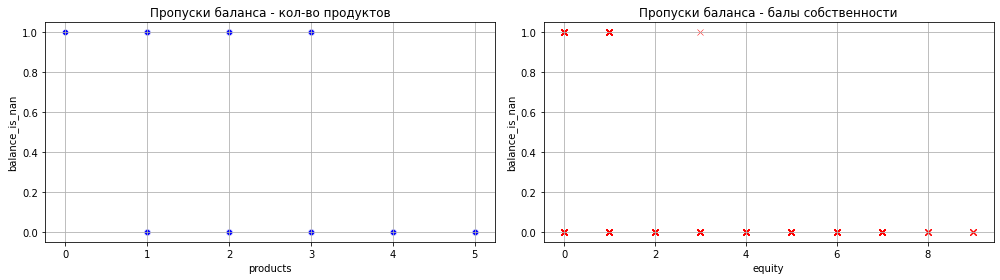

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Products
sns.scatterplot(data=df, x='products', y='balance_is_nan', ax=axes[0], color='blue', marker='o')
axes[0].set_title('Пропуски баланса - кол-во продуктов')
axes[0].set_xlabel('products')
axes[0].set_ylabel('balance_is_nan')
axes[0].grid()

# Equity
sns.scatterplot(data=df, x='equity', y='balance_is_nan', color='red', marker='x')
axes[1].set_title('Пропуски баланса - балы собственности')
axes[1].set_xlabel('equity')
axes[1].set_ylabel('balance_is_nan')
axes[1].grid()

plt.tight_layout()
plt.show()

Из полученных графиков видно:

* Количество продуктов:
    * У всех клиентов с количеством используемых продуктов равным 0 есть пропуски в балансе. Тут можно предположить, что если у клиента нет продуктов банка, то и его баланс будет нулевым.
    * У клиентов с количеством используемых продуктов >3 не встречаются пропуски в балансе

* Баллы собственности:
    * У клиентов с баллами собственности равным 2 и >3 не встречаются пропуски в балансе.
    * При баллах собственности равное 3 - количество пропусков уменьшается.

Проверим клиентов у которых нет продуктов Банка:

In [89]:
df.query('products==0')

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,city_Ростов,city_Рыбинск,city_Ярославль,gender_Ж,gender_М,age_is_nan,balance_is_nan
8957,147837,962.00,79.00,3,NaN,0,0,0,25063.96,1,0,1,0,1,0,0,1


Получился всего один клиент - удалим его:

In [90]:
df = df.query('userid!=147837')

Посчитаем меры центральной тенденции для данных с пропусками и без пропусков по полю `balance`. Выведем средние для зарплаты и возраста:

In [91]:
df.pivot_table(index='balance_is_nan',
               values=['age', 'est_salary'],
               aggfunc='mean')

,age,est_salary
balance_is_nan,,
0,42.92,124520.39
1,42.08,226433.78


По возрасту разница не принципиальная. По зарплате видна существенная разница - у клиентов с пропущенными данными по балансу зарплата выше в 1.8 раза, чем у клиентов без пропусков в балансе.

Посчитаем медианы для количества продуктов и балов собственности:

In [92]:
df.pivot_table(index='balance_is_nan',
               values=['products', 'equity'],
               aggfunc='median')

,equity,products
balance_is_nan,,
0,4,2
1,0,1


По собственности и количеству используемых продуктов данные группы также существенно отличаются: у клиентов с пропущенным балансом медианный бал собственности - 0, а у клиентов без пропусков - 4. Клиенты с пропусками в балансе в основном пользуюьтся одним продуктом, а клиенты без пропусков - двумя.

Проверим отличается ли мода пропусков по клиентам с кредитными картами и без. Предварительно напишем функцию расчёта моды, так как в сводных таблицах pandas нет её кастомной реализации:

In [93]:
def mode(series):
    return series.mode()[0] if not series.mode().empty else None

Количество пропусков от города не зависит.

Проверим моду пропусков по признаку наличия кредитной карты:

In [94]:
df.pivot_table(index='balance_is_nan',
               values='credit_card',
               aggfunc=mode)

,credit_card
balance_is_nan,
0,1
1,1


Пропуски в балансе не связаны с наличием кредитной карты.

Посчитаем средний кредитный рейтинг для пользователей с пропуском баланса и без пропуска:

In [95]:
df.pivot_table(index='balance_is_nan',
               values='score',
               aggfunc='mean')

,score
balance_is_nan,
0,843.74
1,865.31


Разница по кредитному рейтингу не существенная.

Мы выяснили, что пропуски в балансе коррелируют с количеством продуктов и баллами собственности, сгруппируем данные по этим признакам и найдем медианы балансов для данных групп: 

In [96]:
balance_medians = df.query('equity<4 & products<4').pivot_table(index=['equity', 'products'],
                   values='balance',
                   aggfunc='median').reset_index()
balance_medians

,equity,products,balance
0,0,1,127337.41
1,0,2,129005.68
2,0,3,199405.38
3,1,1,191123.46
4,1,2,219025.95
5,1,3,259934.24
6,2,1,273081.54
7,2,2,314188.72
8,2,3,452157.70
9,3,1,384730.71


После проведенного анализа, пропуски по полю `balance` можно классифицировать как MAR-пропуски.

Напишем функцию для заполнения пропусков баланса. Функция для пропущенных значений баланса будет искать соответствующее значение медианы из таблицы `balance_medians` по количеству продуктов и баллам собственности клиента:

In [97]:
def fill_balance(row):
    
    if row['balance_is_nan']:
        equity = row['equity']
        products = row['products']
        balance = balance_medians.query('equity==@equity & products==@products')['balance'].values[0]
        return balance
    else:
        return row['balance']

Заполним пропущенные значения в поле `balance`:

In [98]:
df['balance'] = df.apply(fill_balance, axis=1)

Проверим полученный результат:

In [99]:
df.query('balance_is_nan==1').sample(10)

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,city_Ростов,city_Рыбинск,city_Ярославль,gender_Ж,gender_М,age_is_nan,balance_is_nan
3493,154099,916.00,45.00,0,127337.41,1,1,1,230194.84,0,1,0,0,0,1,0,1
8525,160375,887.00,49.00,0,127337.41,1,1,1,114070.74,0,0,0,1,1,0,0,1
5577,151478,931.00,31.00,0,127337.41,1,1,0,120600.46,0,0,0,1,1,0,0,1
860,147130,922.00,58.00,0,129005.68,2,1,1,83459.32,0,0,0,1,1,0,0,1
1023,170240,714.00,40.00,0,127337.41,1,1,1,311646.73,0,0,0,1,1,0,0,1
6726,219650,745.00,32.00,0,127337.41,1,1,0,189038.11,0,0,1,0,1,0,0,1
3306,136222,937.00,34.00,0,127337.41,1,1,1,143746.66,0,0,0,1,1,0,0,1
2389,197336,956.00,35.00,0,127337.41,1,0,1,235177.58,0,0,0,1,1,0,0,1
3705,222657,920.00,30.00,0,129005.68,2,1,1,227352.83,0,0,0,1,0,1,0,1
259,196871,944.00,69.00,0,127337.41,1,1,0,254548.39,0,0,0,1,1,0,0,1


Пропуски заполнены.

### Приведение типов данных к целевым

При знакомстве с данными обнаружили, что поля с возрастом и кредитным скорингом представлены в вещественном типе. Приведем их их к целочисленному типу:

In [100]:
df['age'] = df['age'].astype('int')
df['score'] = df['score'].astype('int')

### Обработка дубликатов данных

#### Обработка явных дубликатов

Проверим наличие явных дубликатов:

In [101]:
df.duplicated().sum()

0

Явных дубликатов (полных совпадений строк не обнаружено)

#### Обработка неявных дубликатов

Часто встречающиеся неявные дубликаты связанные с ошибками в написании, различием регистра, лишними символами в строковых категориальных данных в нашем датасете отсутствуют (ранее быле преобразованы в бинарные признаки).

Проверим неявные дубликаты по полю `userid`:

In [102]:
df['userid'].duplicated().sum()

50

Найдено 73 одинаковых идентификатора пользователя. Проверим данные дубликаты

In [103]:
df[df['userid'].duplicated(keep=False)].sort_values(by='userid').head(20)

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,city_Ростов,city_Рыбинск,city_Ярославль,gender_Ж,gender_М,age_is_nan,balance_is_nan
1893,116540,883,55,1,362756.49,3,0,1,175920.48,1,0,1,0,1,0,0,0
7694,116540,887,38,0,127337.41,1,0,1,119247.61,0,0,0,1,1,0,0,1
4866,117943,855,32,6,1036832.93,4,1,1,107792.71,1,0,1,0,1,0,0,0
7542,117943,880,40,0,127337.41,1,1,0,137718.93,0,0,0,1,1,0,0,1
5863,120258,908,38,4,2213581.63,2,0,1,160327.77,1,0,1,0,1,0,0,0
5896,120258,905,30,0,127337.41,1,1,1,146427.96,0,0,0,1,0,1,0,1
1411,123461,829,59,0,96222.44,2,0,1,102771.55,1,0,0,1,1,0,0,0
8638,123461,934,34,0,129005.68,2,1,0,291619.27,0,0,1,0,0,1,0,1
9775,124450,758,36,0,73574.07,2,0,1,79963.59,0,0,1,0,1,0,0,0
8164,124450,859,38,6,516811.20,1,1,1,95144.63,1,0,0,1,1,0,0,0


Здесь видим, что клиенты с одинаковыми идентификаторами заметно отличаются друг от друга. Вероятно при подготовке датасета произошла техническая ошибка. 

Так как для дальнейшей работы поле с идентификатором клиента не несет важной информации и клиенты с одинаковыми идентификаторами явно являются разными людьми, такие дубликаты удалять не будем.

### Удаление вспомогательных признаков

Удалим столбцы `userid`, `age_is_nan`, `balance_is_nan` - они не понадобятся в дальнейшей работе:

In [104]:
df = df.drop(columns=['userid', 'age_is_nan', 'balance_is_nan'])

### Выводы по предобработке данных

* Привели наименование столбцов к нижнему регистру
* Закодировали категориальные признаки методом `get_dummies` из библиотеки `Pandas`

**Обработка пропусков**
* Обнаружили две колонки с пропусками - age и balance:
    * Пропуски по поллю `age` 26 шт. или 0.26%
    * Пропуски по поллю `balance` 2295 шт. или 22.95%
* Пропуски по полю `age`:
    * Ни одной значимой корреляции между пропусками и другими признаками не обнаружено, следовательно можно предположить, что данные пропуски возникли случайно, то есть данный вид пропусков можно классифицировать как MCAR-пропуски (пропуски данных происходят случайным образом, и их наличие не зависит ни от наблюдаемых, ни от ненаблюдаемых данных).
    * Пропуски удалили.

* Пропуски по полю `balance`:
    * Пропуски в балансе коррелируют с количеством продуктов и баллами собственности
    * Пропуски в балансе можно классифицировать как MAR-пропуски (пропуски зависят от наблюдаемых данных, но не от самих пропущенных значений)
    * Для заполнения пропусков подготовили сводную таблицу по количеству используемых продуктов и баллам собственности и посчитали медианные значения для каждой группы. Функцией заполнили все пропущенные значения в зависимости от того в какую группу попал клиент с пропущенным балансом по количеству используемых продуктов и баллам собственности.
    
**Обработка типов данных**
* Поля `age` и `score` представленные в исходном датасете в вещественном типе привели к целочисленному типу данных.

**Обработка дубликатов данных**
* Явных дубликатов (полных совпадений строк не обнаружено)
* Найдены 73 дубликата по полю `userid`, но признаки клиентов с одинаковыми идентификаторами отличаются, что говорит о возможной технической ошибке при выгрузке данных.
* В результате обработки дубликатов данные не удалялись.

* Удалены вспомогательные столбцы `userid`, `age_is_nan`, `balance_is_nan`.

## Исследовательский анализ данных

### Описательная статистика признаков

Для снижения количества повторяющегося кода, напишем функции для описания и визуализации распределений признаков и для определения количества корзин при построении гистограмм.

Так как при большом количестве корзин построение гистограмм с указанием такого количества корзин работает нестабильно, ограничим их следующим образом:
* если разница между максимумом и минимумом признака не превышает величину корня квадратного из длины признака, то в качестве количества корзин возьмем разницу между максимумом и минимумом признака, увеличенную на 1
* если разница между максимумом и минимумом признака превышает величину корня квадратного из длины признака, то в качестве количества корзин возьмем корень из длины признака.
* при возврате значения функцие возвращаться будет минимальное из полученного количества корзин и 50.

Напишем функцию определения количества корзин:

In [105]:
def get_bins_number(data, feature):
    '''
    Возвращает оптимальное количество корзин для построения гистограмм
    Параметры:
    data (DataFrame): датасет с данными
    feature (str): имя признака
    '''
    # Определение корзин для данных с большой размерностью
    if (data[feature].max() - data[feature].min()) > np.sqrt(len(data[feature])):
        bin_num = int(np.sqrt(len(data[feature])))
                      
    else:
        bin_num = int(data[feature].max() - data[feature].min() + 1)
    
    return min(bin_num, 50)

Напишем функцию для описания признаков и визуализации распределений:

In [106]:
def describe_feature(data, kind, feature, hue, level=None):
    '''
    Функция для автоматизации описания признаков датасета и визуализации распределений.
    Параметры:
    data (DataFrame): датасет с данными
    kind (str): вид признака - 'categorical' (категориальный/дискретный), 'continuous' (непрерывный)
    feature (str): имя признака
    hue (str): признак для разбивки
    level (Series): парамметр для подсчета среднего уровня
    '''        
    
    # Описание непрерывных данных
    if kind == 'continuous':
        num_bins = get_bins_number(data, feature)
        print(f'Min: {data[feature].min()}')
        print(f'Max: {data[feature].max()}')
        print(f'Среднее: {data[feature].mean():.2f}')
        print(f'Медиана: {data[feature].median():.2f}')
        print(f'Ст. откл-е: {data[feature].std():.2f}')
        
        plt.figure(figsize=(10, 6))
        sns.histplot(data=data, x=feature, hue=hue, bins=num_bins, stat='density', common_norm=False, kde=True, binwidth=1)
        
        for artist in plt.gca().patches:
            artist.set_alpha(0.5)
        
        plt.title(f'Распределение для {feature}')
        plt.xlabel(feature)
        plt.ylabel('Плотность')
        plt.show();
        
    # Визуализация категориальных данных и их связь с оттоком
    if kind == 'categorical':
        
        if level==None:
            avg_churn = data[hue].mean()
        else:
            avg_churn = level
        
        feature_churn = data.groupby(feature)[hue].mean().reset_index()
        feature_count = data.groupby(feature).size().reset_index(name='count')
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Барплото
        sns.barplot(x=feature,
                    y=hue,
                    data=feature_churn,
                    ax=axes[0],
                    order=feature_churn.sort_values(feature)[feature],
                    palette='muted')
        
        axes[0].axhline(avg_churn, 
                        color='red', 
                        linestyle='--', 
                        label=f'Средний отток ({avg_churn:.2%})')
        
        axes[0].set_title(f'Влияние {feature} на отток')
        axes[0].set_xlabel(feature)
        axes[0].set_ylabel('Уровень оттока')
        
        # Круговая диаграмма
        axes[1].pie(feature_count['count'], 
                    labels=feature_count[feature], 
                    autopct='%1.1f%%', 
                    startangle=90, 
                    colors=sns.color_palette("muted"))
        
        axes[1].set_title(f'Доли категорий {feature}')
        axes[1].axis('equal')
        
        plt.tight_layout()
        plt.show();

#### Описние признака `age`

Опишем непрерывный численный признак возраста клиентов:

Min: 18
Max: 86
Среднее: 42.73
Медиана: 40.00
Ст. откл-е: 12.18


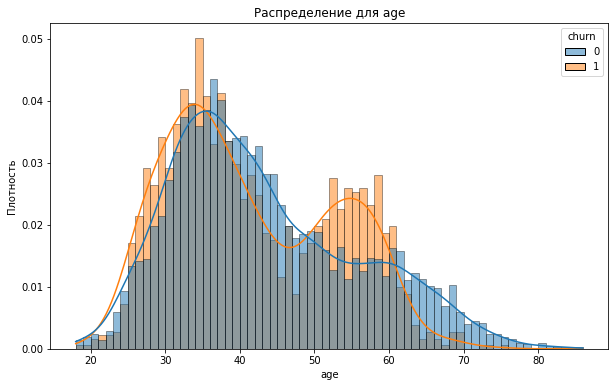

In [107]:
describe_feature(data=df,
                 kind='continuous',
                 feature='age',
                 hue='churn')

* Возраст клиентов Банка находится в диапозоне 18-86 лет.
* На гистограмме видим два пика плотности клиентов по возрастам - первый находится между 30 и 40 годами, второй меньший пик - 50-60 лет.
* Средний возраст клиента - 43 года.
* Возраст основной части клиентов Банка - 31 - 55 лет.
* После 60 лет клиенты менее склонны к оттоку, также с 40 до 50 лет клиенты реже склонны к оттоку.
* Наибольшая доля клиентов склонных к оттоку находится в диапозонах 25-35 лет и 51-60 лет.

#### Описние признака `score`

Опишем непрерывный численный признак баллов кредитного скорринга клиентов:

Min: 642
Max: 1000
Среднее: 848.67
Медиана: 853.00
Ст. откл-е: 65.39


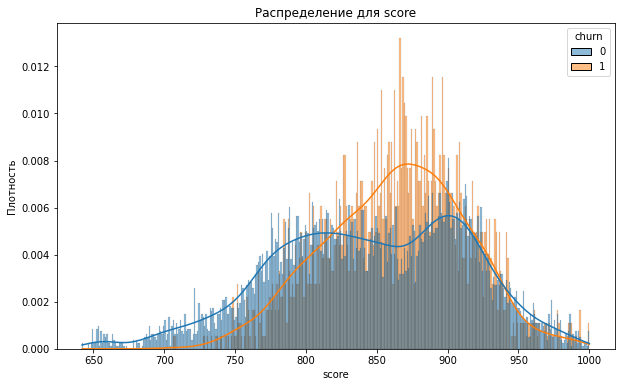

In [108]:
describe_feature(data=df,
                 kind='continuous',
                 feature='score',
                 hue='churn')

* Баллы кредитного рейтинга варьируются в диапозоне 642 - 1000.
* Средний кредитный рейтинг клиентов - 849 баллов.
* Видим скошенное влево распределение - небольшое количество клиентов с низким кредитным рейтингом (<775) и как правило не склонных к оттоку.
* Основная часть клиентов имеет кредитный рейтинг в диапозоне 780-900 баллов.
* В диапозоне 825 - 900 преобладают клиенты склонные к оттоку, пик приходится примерно на 875 баллов.

Таким образом видим, что клиенты со средним и высоким кредитным рейтингом склонны к оттоку, это необходимо иметь в виду при планировании маркетинговых акций и формировании персональных предложений для клиентов.

#### Описние признака `balance`

Опишем непрерывный численный признак баланса клиентов. Так как seaborn работает нестабильно с числами большой размерности и большим количеством корзин, будем использовать библиотеку matplotlib:

Min: 0.0
Max: 119113552.01
Среднее: 668402.41
Медиана: 376312.14
Ст. откл-е: 1763839.28


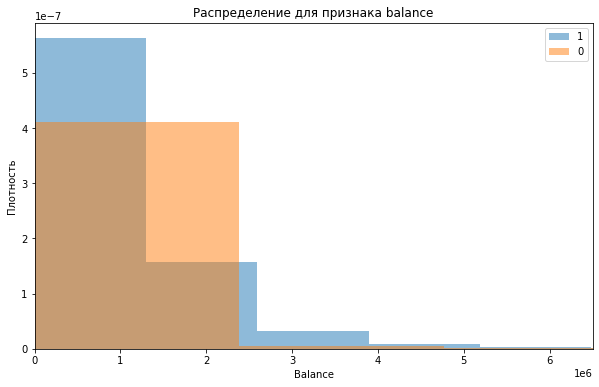

In [109]:
print(f"Min: {df['balance'].min()}")
print(f"Max: {df['balance'].max()}")
print(f"Среднее: {df['balance'].mean():.2f}")
print(f"Медиана: {df['balance'].median():.2f}")
print(f"Ст. откл-е: {df['balance'].std():.2f}")

plt.figure(figsize=(10, 6))

# Построение гистограммы для клиентов, которые ушли
plt.hist(df.query('churn==1')['balance'], bins=50, alpha=0.5, label='1', density=True)

# Построение гистограммы для клиентов, которые не ушли
plt.hist(df.query('churn==0')['balance'], bins=50, alpha=0.5, label='0', density=True)

plt.xlabel('Balance')
plt.xlim(0,6500000)
plt.ylabel('Плотность')
plt.title('Распределение для признака balance')
plt.legend()
plt.show()

* Максимальный баланс клиента - 119 млн руб.
* Видим скошенное вправо распределение с длинным "хвостом" аномально высоких балансов
* Средний баланс - 668 тыс. руб. медианный - 376 тыс.руб. Средний значительно выше медианного за счет наличия экстремально больших значений
* Основная доля значений находится в диапозоне 0-2.5 млн.
* У клиентов с балансом до 1.2 млн и свыше 2.6 млн доля склонных к оттоку выше.

#### Описние признака `est_salary`

Опишем непрерывный численный признак оценочной зарплаты клиента:

Min: 2546.3
Max: 1395064.45
Среднее: 147799.12
Медиана: 119643.06
Ст. откл-е: 139287.08


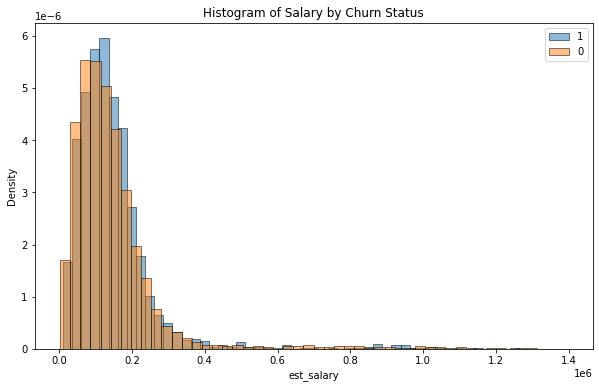

In [110]:
print(f"Min: {df['est_salary'].min()}")
print(f"Max: {df['est_salary'].max()}")
print(f"Среднее: {df['est_salary'].mean():.2f}")
print(f"Медиана: {df['est_salary'].median():.2f}")
print(f"Ст. откл-е: {df['est_salary'].std():.2f}")

plt.figure(figsize=(10, 6))

# Построение гистограммы для клиентов, которые ушли
plt.hist(df.query('churn==1')['est_salary'], bins=get_bins_number(df, 'est_salary'), alpha=0.5, label='1', density=True, edgecolor='black')

# Построение гистограммы для клиентов, которые не ушли
plt.hist(df.query('churn==0')['est_salary'], bins=get_bins_number(df, 'est_salary'), alpha=0.5, label='0', density=True, edgecolor='black')

plt.xlabel('est_salary')
plt.ylabel('Density')
plt.title('Histogram of Salary by Churn Status')
plt.legend()
plt.show()

* Видим скошенное вправо распределение с длинным "хвостом" нетипично высоких зарплат
* Основная часть клиентов получает зарплату в диапозоне 50-200 тыс. руб.
* Среди клиентов с зарплатой до 100 тыс. доля отточных ниже, чем лояльных
* Среди клиентов с зарплатой от 100 до 200 тыс. доля склонных к оттоку выше.
* У клиентов с зарплатой от 200 тыс. доли склонных и не склонных практически идентичны.
* Зарплаты клиентов варьируются в диапозоне 3 тыс - 1.4 млн руб.
* Зарплаты выше 300 тыс встречаются крайне редко

#### Описние признака `equity`

Опишем дискретный численный признак баллов собственности клиентов:

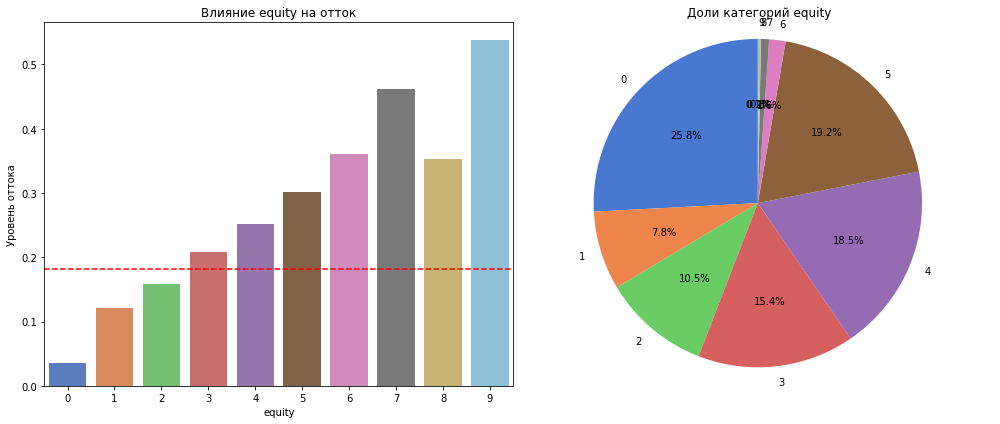

In [111]:
describe_feature(data=df,
                 kind='categorical',
                 feature='equity',
                 hue='churn')

* Из полученного графика видим, что наиболее лояльные клиенты с уровнем оттока ниже среднего имеют в собственности не более двух объектов. Максимальный уровень лояльности - у клиентов без собственности (менее 5%).

* Более всего к оттоку склонны клиенты с большим количеством собственности - более 5 объектов и т.д.

* Меньше всего клиентов с количеством собственности более 5.
* Клиенты с количеством собственности до 5 распределны относительно равномерно, особо выделяется группа без собственности - 26% и клиенты имеющие 5 объектов собственности - 19%.

#### Описние признака `products`

Опишем дискретный численный признак количества используемых клиентами продуктов:

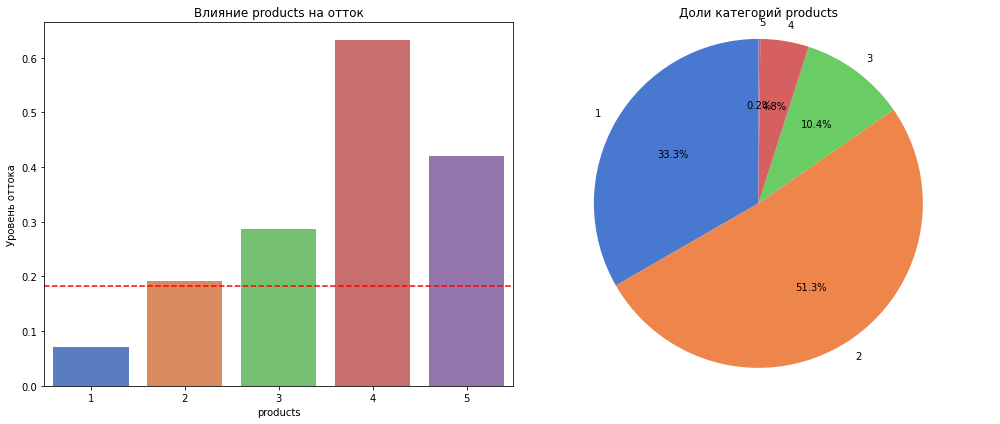

In [112]:
describe_feature(data=df,
                 kind='categorical',
                 feature='products',
                 hue='churn')

* Самые лояльные клиенты - те, кто пользуются только одним продуктом.
* Клиенты с двумя продуктами находятся примерно на уровне среднего оттока по всем клиентам.
* Самые нелояльные клиенты те, у которых нет ни одного продукта банка (что вполне логично), но такой пользователь всего один в датасете.
* У клиентов пользующихся разнообразными продуктами банка (3-5 продукта) уровень оттока существенно выше среднего.

* Чаще всего клиенты пользуются одним или двумя продуктами Банка.
* Клиентов пользующихся более чем тремя продуктами очень мало.

#### Описние признака `credit_card`

Проверим как связаны категориальный бинарный признак наличия кредитной карты Банка и склонность клиентов к оттоку:

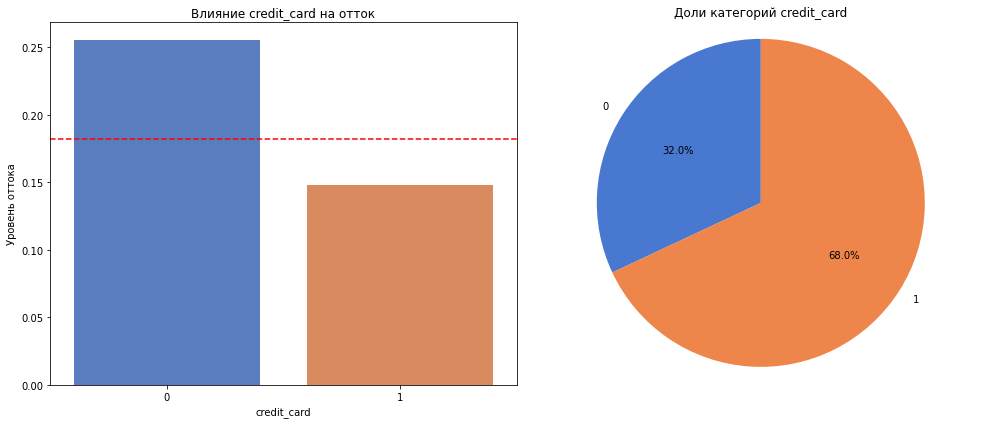

In [113]:
describe_feature(data=df,
                 kind='categorical',
                 feature='credit_card',
                 hue='churn')

* Из полученного графика видно, что клиенты имеющие кредитную карту Банка значительно лояльнее чем клиенты без кредитной карты.

* 68% клиентов Банка имеют кредитную карту, но у оставшихся 32% склонность к оттоку выше среднего (примерно четверть из них может уйти из Банка).

#### Описние признака `last_activity`

Проверим как свзан категориальный бинарный признак активности клиентов и склонность к оттоку:

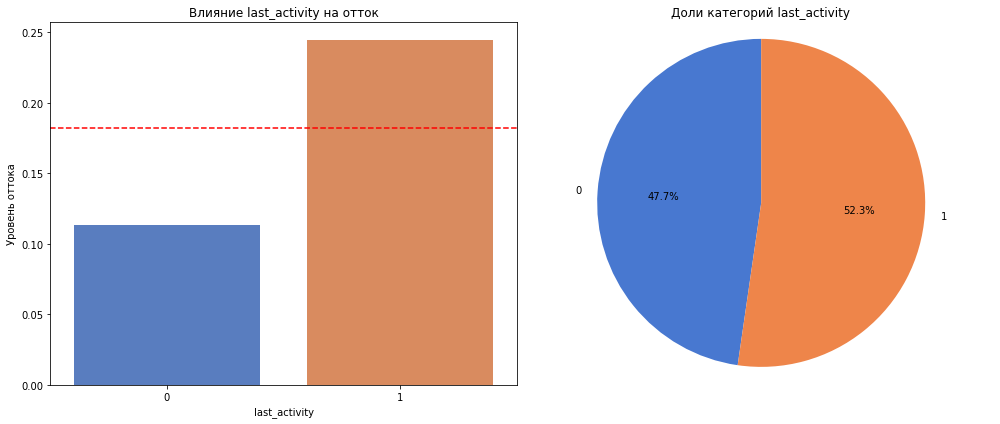

In [114]:
describe_feature(data=df,
                 kind='categorical',
                 feature='last_activity',
                 hue='churn')

* Получилась неочевидная зависимость - у активных клиентов склонность к оттоку выше средней, в то время как у неактивных клиентов уровень оттока ниже среднего.

* Активные и неактивные клиенты распределены практически поровну.

#### Описние признака `gender`

Проверим как связан категориальный признак пола клиента и склонность к оттоку. Для этого сначала раскодируем ранее созданные признаки пола и города и сохраним в отдельный датасет:

In [115]:
df_uncoded = df.copy()

df_uncoded['city'] = df_uncoded[['city_Ростов', 'city_Рыбинск', 'city_Ярославль']].idxmax(axis=1).str.replace('city_', '')

df_uncoded['gender'] = df_uncoded[['gender_Ж', 'gender_М']].idxmax(axis=1).str.replace('gender_', '')


df_uncoded = df_uncoded.drop(columns=['city_Рыбинск', 'city_Ростов', 'city_Ярославль', 'gender_Ж', 'gender_М'])

Посмотрим на связь пола со склонностью к оттоку:

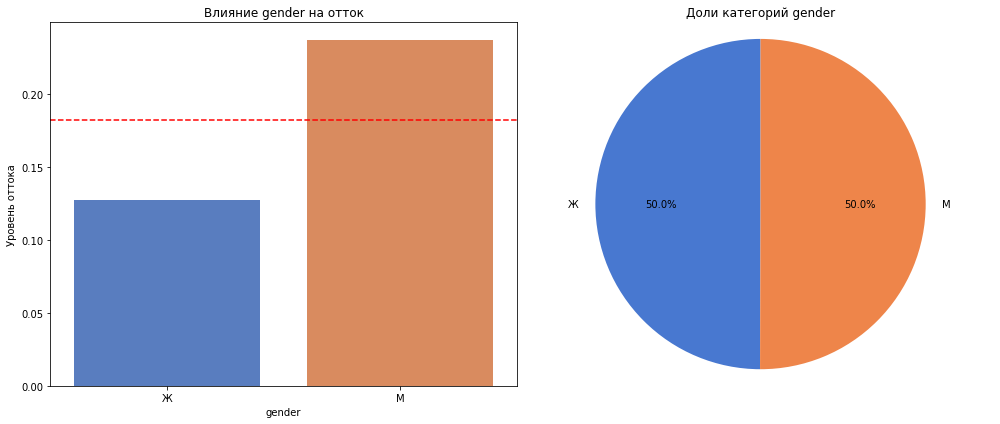

In [116]:
describe_feature(data=df_uncoded,
                 kind='categorical',
                 feature='gender',
                 hue='churn')

* Получили, что женщины более консервативны и склонность к оттоку у них ниже среднего, а мужчины наоборото более склонны к оттоку.

* Клиенты по полу распределны поровну.

#### Описние признака `city`

Проверим как отличаются города по уровню отточности:

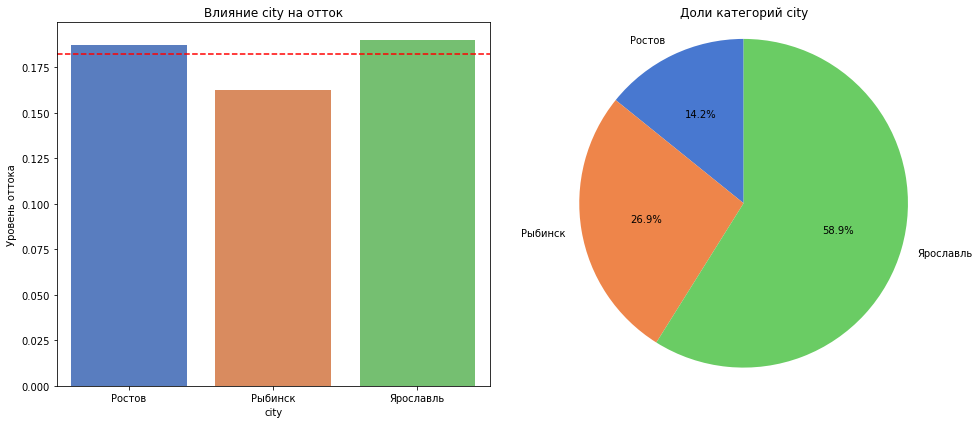

In [117]:
describe_feature(data=df_uncoded,
                 kind='categorical',
                 feature='city',
                 hue='churn')

* 59% клиентов Банка живут в Ярославле (областной центр)
* Самые лояльные клиенты живут в Рыбинске.
* Склонность к оттоку у клиентов из Ростова и Ярославля сопоставима и чуть выше среднего уровня.

### Анализ средних значений признаков по группам отточности

В данном разделе посчитаем меры центральной тенденции для основных признаков датасета в разбивке по группам отточности.

Для начала напишем функцию для подсчета моды, так как у датафреймов нет такой встроенной функции:

In [118]:
def mode(series):
    return series.mode().iloc[0] if not series.mode().empty else None

Сгруппируем данные по признаку отточности и для каждого посчитаем среднее, медиану и моду, а затем транспонируем полученную таблицу, чтобы признаки оттока оказались в столбцах:

In [119]:
central_measures_df = df.groupby('churn').agg(['mean','median', mode]).T.reset_index()

Проверим результат:

In [120]:
central_measures_df.head()

churn,level_0,level_1,0,1
0,score,mean,845.40,863.36
1,score,median,848.00,866.00
2,score,mode,900.00,866.00
3,age,mean,43.02,41.43
4,age,median,40.00,39.00


Переименуем столбцы полученной таблицы:

In [121]:
central_measures_df.columns = ['feature', 'measure', 'not_churn', 'churn']

Добавим столбец с относительной разницей мер в процентах между группами отточности:

In [122]:
central_measures_df['rel_dif'] = (central_measures_df['churn'] - central_measures_df['not_churn']) / central_measures_df['not_churn'] * 100

Проверим полученный результат:

In [123]:
central_measures_df

,feature,measure,not_churn,churn,rel_dif
0,score,mean,845.40,863.36,2.13
1,score,median,848.00,866.00,2.12
2,score,mode,900.00,866.00,-3.78
3,age,mean,43.02,41.43,-3.70
4,age,median,40.00,39.00,-2.50
5,age,mode,36.00,34.00,-5.56
6,equity,mean,2.38,3.76,58.24
7,equity,median,3.00,4.00,33.33
8,equity,mode,0.00,5.00,inf
9,balance,mean,565959.51,1127930.39,99.30


Удалим лишние записи:

In [124]:
rows_to_delete = [2, 5, 6, 8, 11, 12, 14, 16, 17, 19, 20, 23]

central_measures_df = central_measures_df.drop(rows_to_delete)

central_measures_df = central_measures_df[central_measures_df.index<24]

Напишем функцию для заливки ячеек в зависимости от значения:

In [125]:
def color_cells(val):
    if val < -5:
        return 'background-color: red'
    elif val > 5:
        return 'background-color: green'

Прокрасим столбец с относительной разницей мер для наглядности:

In [126]:
measures_pivot = central_measures_df.style.applymap(color_cells, subset=['rel_dif'])

In [127]:
measures_pivot

,feature,measure,not_churn,churn,rel_dif
0,score,mean,845.396199,863.361936,2.125126
1,score,median,848.000000,866.000000,2.122642
3,age,mean,43.020846,41.429593,-3.698796
4,age,median,40.000000,39.000000,-2.500000
7,equity,median,3.000000,4.000000,33.333333
9,balance,mean,565959.511875,1127930.388933,99.295244
10,balance,median,321642.560000,775399.470000,141.074897
13,products,median,2.000000,2.000000,0.000000
15,credit_card,mean,0.708890,0.551705,-22.173401
18,last_activity,mean,0.482894,0.702420,45.460566


#### Выводы по анализу средних значений признаков по группам отточности

* Обе группы клиентов не существенно отличаются по признаку средних/медианных балоов кредитного скорринга (у клиентов с оттоком они выше на 2%)
* Средний возраст лояльного клиента - 43 года, склонного к оттоку - 41. Медианы для обеих групп меньше среднего (40 и 39 соответственно), значит есть смещение возраста клиентов в большую сторону.
* У клиентов склонных к оттоку медианный бал собственности - 4, у лояльных клиентов - 3.
* Существенно отличаются средние и медианные балансы клиентов из двух групп - у клиентов склонных к оттоку средний баланс выше чем у лояльных на 99%, медианный на 141%. Различие средних и медиан также объясняется смещением распределения вправо (наличие аномально высоких значений)
* Медианное количество используемых продуктов для двух групп не отличается и равно двум.
* У клиентов склонных к оттоку на 22% реже встречается кредитная карта Банка.
* Клиенты склонные к оттоку на 45% активнее лояльных клиентов. Так среди лояльных клиентов активны только 48%, среди клиентов склонных к оттоку - 70%.
* Средние зарплаты обеих групп отличаются не существенно, а медианная зарплата клиентов склонных к оттоку на 6% выше чем у лояльных клиентов. Средние зарплаты также получились выше медианных, что говорит о смещении рапспределения в большую сторону (наличие аномально высоких зарплат у некоторых клиетов).

### Сравнение портретов пользователей по группам отточности

Суммируем все наблюдения по характерным признакам для групп отточности. Выведем данные по основным признакам в разбивке пола и города клиента:

In [128]:
features_list = ('age', 'equity', 'balance', 'est_salary', 'credit_card', 'last_activity')

continuous_features = ('age', 'balance', 'est_salary')
discrete_features = ('equity')
categorical_features = ('credit_card', 'last_activity')

for feature in features_list:
    print()
    print(f'Характеристики по {feature}')
    
    if feature in continuous_features:
        portret = (df_uncoded.groupby(['churn', 'city', 'gender'])[feature]
               .agg(['mean','median', 'count']).T
               .reset_index()
              )
        display(portret)
    
    if feature in discrete_features:
        portret = (df_uncoded.groupby(['churn', 'city', 'gender'])[feature]
               .agg(['median', 'count']).T
               .reset_index()
              )
        display(portret)
    
    if feature in categorical_features:
        portret = (df_uncoded.groupby(['churn', 'city', 'gender'])[feature]
               .agg(['mean', 'count']).T
               .reset_index()
              )
        display(portret)
    
    print(20*'==')
    print()


Характеристики по age


churn    index      0                                               1         \
city           Ростов        Рыбинск         Ярославль         Ростов          
gender              Ж      М       Ж       М         Ж       М      Ж      М   
0         mean  47.40  40.71   45.91   40.61     45.01   39.67  43.60  42.40   
1       median  45.00  39.00   43.00   39.00     42.00   38.00  41.00  40.00   
2        count 643.00 508.00 1235.00 1011.00   2469.00 2289.00  90.00 175.00   

churn                                   
city   Рыбинск        Ярославль         
gender       Ж      М         Ж      М  
0        46.04  40.47     42.30  39.92  
1        50.00  38.00     39.00  37.00  
2       138.00 298.00    407.00 710.00



Характеристики по equity


churn    index      0                                         1               \
city           Ростов      Рыбинск       Ярославль       Ростов      Рыбинск   
gender              Ж    М       Ж     М         Ж     М      Ж    М       Ж   
0       median      3    3       3     2         3     2      4    4       4   
1        count    643  508    1235  1011      2469  2289     90  175     138   

churn                       
city        Ярославль       
gender    М         Ж    М  
0         4         4    4  
1       298       407  710



Характеристики по balance


...

churn    index         0                                                    \
city              Ростов             Рыбинск           Ярославль             
gender                 Ж         М         Ж         М         Ж         М   
0         mean 101133.87 118327.73 126688.26 145460.60 149450.39 177646.76   
1       median  91192.35 107421.98 103439.66 124587.71 117259.62 139443.76   
2        count    643.00    508.00   1235.00   1011.00   2469.00   2289.00   

churn          1                                                    
city      Ростов             Рыбинск           Ярославль            
gender         Ж         М         Ж         М         Ж         М  
0      125133.98 122905.83 120201.25 139156.54 149168.80 166443.95  
1      111514.75 106099.43 114778.35 120689.10 127743.30 135661.54  
2          90.00    175.00    138.00    298.00    407.00    710.00



Характеристики по credit_card


churn   index      0                                               1         \
city          Ростов        Рыбинск         Ярославль         Ростов          
gender             Ж      М       Ж       М         Ж       М      Ж      М   
0        mean   0.53   0.66    0.63    0.72      0.69    0.83   0.38   0.56   
1       count 643.00 508.00 1235.00 1011.00   2469.00 2289.00  90.00 175.00   

churn                                   
city   Рыбинск        Ярославль         
gender       Ж      М         Ж      М  
0         0.36   0.58      0.47   0.64  
1       138.00 298.00    407.00 710.00



Характеристики по last_activity


churn   index      0                                               1         \
city          Ростов        Рыбинск         Ярославль         Ростов          
gender             Ж      М       Ж       М         Ж       М      Ж      М   
0        mean   0.52   0.48    0.54    0.51      0.46    0.46   0.72   0.63   
1       count 643.00 508.00 1235.00 1011.00   2469.00 2289.00  90.00 175.00   

churn                                   
city   Рыбинск        Ярославль         
gender       Ж      М         Ж      М  
0         0.78   0.72      0.82   0.63  
1       138.00 298.00    407.00 710.00

#### Выводы по сравнению портретов пользователей по группам отточности

**Лояльные клиенты**
* Женщины в возрасте 45-47 лет проживающие преимущественно в Рыбинске и Ярославле
    * Имеют три объекта собственности
    * Получают зарплату в диапозоне 101-150 тыс руб.
    * Баланс счета 518-566 тыс.руб.
    * Имеют кредитную карту 53-69% в зависимости от города
    * Активны 46-54% клиентов

* Мужчины в возрасте 39-40 лет проживающие преимущественно в Рыбинске и Ярославле:
    * Имеют два объекта собственности
    * Получают зарплату в диапозоне 118-180 тыс. руб.
    * Баланс счета 473-645 тыс. руб.
    * Имеют кредитную карту 63-83% в зависимости от города
    * Активны 46-51% клиентов

* Лояльные клиенты-женщины старше аналогичной группы мужчин, имеют больше недвижимости по сравнению с мужчинами, реже имеют кредитную карту, уровень зарплаты ниже чем у мужчин.


**Клиенты склонные к оттоку**
* Женщины в возрасте 42-46 лет проживающие преимущественно в Рыбинске и Ярославле
    * Имеют четыре объекта собственности
    * Получают зарплату в диапозоне 120-149 тыс руб.
    * Баланс счета 800-1063 тыс.руб.
    * Имеют кредитную карту 36-47% в зависимости от города
    * Активны 72-82% клиентов

* Мужчины в возрасте 39-40 лет проживающие преимущественно в Рыбинске и Ярославле:
    * Имеют четыре объекта объекта собственности
    * Получают зарплату в диапозоне 123-166 тыс. руб.
    * Баланс счета 948-1367 тыс. руб.
    * Имеют кредитную карту 56-64% в зависимости от города
    * Активны 63-72% клиентов
    
Характерные отличия получившихся групп:
* Женщины старше мужчин, реже имеют кредитную карту чем мужчины, получают меньшую зарплату, имеют меньше накопленией, реже склонны к оттоку.
* Мужчины чаще имеют кредитные карты, получают зарплату больше женщин и имеют более высокие накопления.
* Лояльные клиенты имеют меньше собственности, меньшие накопления, чаще пользуются кредитными картами по сравнению с клиентами, склонными к оттоку.

### Анализ корреляции признаков датасета

Для анализа корреляции признаков датасета будем использовать библиотек `phik`.

`phik` - эта библиотека работает сразу со всеми признаками, считая нужный тип корреляции в зависимости от принадлежности признака к той или иной категории. 

Плюс библиотеки в том, что она улавливает также нелинейные зависимости, 
Минус - не показывает направление зависимости. 

Также при использовании `phik` важно настроить параметр `interval_cols`, передав ему список непрерывных признаков.

Зададим список непрерывных признаков:

In [129]:
interval_cols = ['score', 'age', 'balance', 'est_salary']

Вычислим матрицу корреляций:

In [130]:
cor_matrix = phik_matrix(df_uncoded, interval_cols=interval_cols)

Визуализируем полученную матрицу корреляцию с помощью тепловой карты:

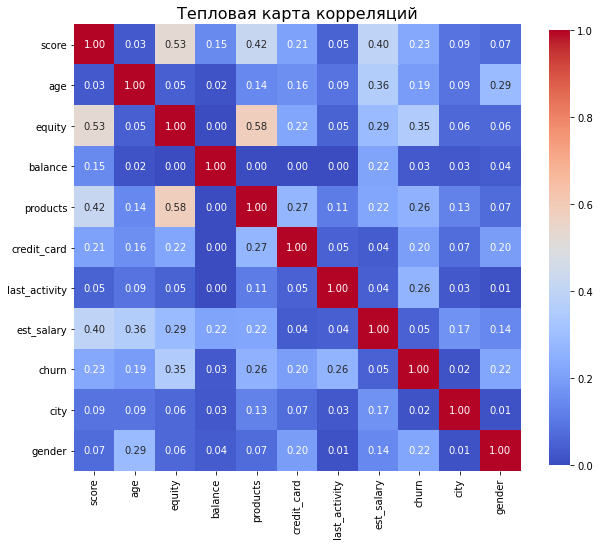

In [131]:
plt.figure(figsize=(10, 10))

sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True, cbar_kws={"shrink": .8})

plt.title('Тепловая карта корреляций', fontsize=16)

plt.show()

Согласно шкале Чеддока, используемой для оценки силы корреляции между признаками, выделяются следующие категории:
* 0 - 0.19 - очень слабая корреляция
* 0.20 - 0.39 - слабая корреляция
* 0.40 - 0.59 - умеренная корреляция
* 0.60 - 0.79 - сильная корреляция
* 0.80 - 1.00 - очень сильная корреляция

* Корреляция с признакоом оттока:
    * сильной и умеренной корреляции нет ни с одним признаком
    * слабая коррелляция есть с количеством используемых продуктов (0.26), с полом (0.22), кредитным скоррингом (0.23), активностью (0.26), наличием кредитной карты (0.20) и количеством собственности (0.35) - сегментация пользователей по всем этим признакам была приведена выше.
* Сильные корреляции между другими признаками в датасете отсутствуют
* Умеренные корреляции:
    * кредитны скорринг - количество продуктов (0.42)
    * количество собственности - кредитный скорринг (0.53) - логичная связь, чем больше собственности тем выше должен быть кредитный рейтинг
    * количество собственности - количество используемых продуктов (0.58)
    * наличие кредитной карты - количество используемых продуктов (0.27) - логичная связь, наличие кредитной карты расширяет количество базовых услуг банка.
    * зарплата - кредитный скорринг (0.40) - логичная свзяь, чем больше доход тем выше кредитный рейтинг
* Слабые корреляции:
    * кредитный скорринг - наличие кредитной карты (0.21)
    * возраст - зарплата (0.36) - обычно с возрастом растет доход
    * возраст - пол (0.29) - ранее обнаружили, что клиенты женского пола представленные в датасете старше чем клиенты мужского пола
    * количество собственности - наличие кредитной карты (0.22)
    * количество собственности - зарплата (0.29)
    * баланс - зарплата (0.22)
    * наличие кредитной карты - пол (0.20) - ранее обнаружили, что клиенты-женщины реже владеют кредитной картой
* Остальные признаки имеют очень слабую корреляцию.

#### Выводы по анализу корреляции признаков датасета

* Корреляция с признакоом оттока:
    * сильной и умеренной корреляции нет ни с одним признаком
    * умеренная корреляция (0.44) есть с количеством используемых продуктов
    * слабая коррелляция есть с количеством используемых продуктов (0.26), с полом (0.22), кредитным скоррингом (0.23), активностью (0.26), наличием кредитной карты (0.20) и количеством собственности (0.35) - сегментация пользователей по всем этим признакам была приведена выше.
* Сильные корреляции между другими признаками в датасете отсутствуют
* Умеренные корреляции:
    * кредитны скорринг - количество продуктов (0.42)
    * количество собственности - кредитный скорринг (0.53) - логичная связь, чем больше собственности тем выше должен быть кредитный рейтинг
    * количество собственности - количество используемых продуктов (0.58)
    * наличие кредитной карты - количество используемых продуктов (0.27) - логичная связь, наличие кредитной карты расширяет количество базовых услуг банка.
    * зарплата - кредитный скорринг (0.40) - логичная свзяь, чем больше доход тем выше кредитный рейтинг
* Все остальные признаки имеют слабую и очень слабую корреляцию.

### Выводы по исследовательскому анализу данных

**Описательная статистика признаков**
* Основная информация о клиентах:
    * `age`:
        * Возраст клиентов Банка находится в диапозоне 18-86 лет.
        * На гистограмме распределения два пика плотности клиентов по возрастам - первый находится между 30 и 40 годами, второй меньший пик - 50-60 лет.
        * Средний возраст клиента - 43 года.
        * Возраст основной части клиентов Банка - 31 - 55 лет.
        * После 60 лет клиенты менее склонны к оттоку, также с 40 до 50 лет клиенты реже склонны к оттоку.
        * Наибольшая доля клиентов склонных к оттоку находится в диапозонах 25-35 лет и 51-60 лет. 
    
    * `gender`:
        * Получили, что женщины более консервативны и склонность к оттоку у них ниже среднего, а мужчины наоборото более склонны к оттоку.
        * Клиенты по полу распределны поровну.
    
    * `city`:
        * 59% клиентов Банка живут в Ярославле (областной центр)
        * Самые лояльные клиенты живут в Рыбинске.
        * Склонность к оттоку у клиентов из Ростова и Ярославля сопоставима и чуть выше среднего уровня.

* Финансовые показатели клиентов:
    
    * `score`:
        * Баллы кредитного рейтинга варьируются в диапозоне 642 - 1000.
        * Средний кредитный рейтинг клиентов - 849 баллов.
        * Основная часть клиентов имеет кредитный рейтинг в диапозоне 780-900 баллов.
        * В диапозоне 825 - 900 преобладают клиенты склонные к оттоку, пик отточности приходится примерно на 875 баллов.
        * Клиенты со средним и высоким кредитным рейтингом склонны к оттоку, это необходимо иметь в виду при планировании маркетинговых акций и формировании персональных предложений для клиентов.
    
    * `equity`:
        * Наиболее лояльные клиенты с уровнем оттока ниже среднего имеют в собственности не более двух объектов. Максимальный уровень лояльности - у клиентов без собственности (менее 5%).
        * Более всего к оттоку склонны клиенты с большим количеством собственности - более 5 объектов.
        * Меньше всего клиентов с количеством собственности более 5.
        * Клиенты с количеством собственности до 5 распределны относительно равномерно, особо выделяется группа без собственности - 26% и клиенты имеющие 5 объектов собственности - 19%.
    
    * `balance`:
        * Максимальный баланс клиента - 119 млн руб.
        * Видим скошенное вправо распределение с длинным "хвостом" аномально высоких балансов
        * Средний баланс - 668 тыс. руб. медианный - 376 тыс.руб. Средний значительно выше медианного за счет наличия экстремально больших значений
        * Основная доля значений находится в диапозоне 0-2.5 млн.
        * У клиентов с балансом до 1.2 млн и свыше 2.6 млн доля склонных к оттоку выше.
        
    * `est_salary`:
        * Зарплаты клиентов варьируются в диапозоне 3 тыс - 1.4 млн руб.
        * Основная часть клиентов получает зарплату в диапозоне 50-200 тыс. руб.
        * Среди клиентов с зарплатой до 100 тыс. доля отточных ниже, чем лояльных
        * Среди клиентов с зарплатой от 100 до 200 тыс. доля склонных к оттоку выше.
        * У клиентов с зарплатой от 200 тыс. доли склонных и не склонных к оттоку практически идентичны.
        * Зарплаты выше 300 тыс встречаются крайне редко


* Показатели взаимодействия с банком:
    * `products`:
        * Самые лояльные клиенты - те, что пользуются только одним продуктом.
        * Клиенты с двумя продуктами находятся примерно на уровне среднего оттока по всем клиентам.
        * У клиентов пользующихся разнообразными продуктами банка (3-5 продукта) уровень оттока существенно выше среднего.
        * Чаще всего клиенты пользуются одним или двумя продуктами Банка.
        * Клиентов пользующихся более чем тремя продуктами очень мало.
        
    * `credit_card`:
        * Из полученного графика видно, что клиенты имеющие кредитную карту Банка значительно лояльнее чем клиенты без кредитной карты.
        * 68% клиентов Банка имеют кредитную карту, но у оставшихся 32% склонность к оттоку выше среднего (примерно четверть из них может уйти из Банка).
    
    * `last_activity`:
        * У активных клиентов склонность к оттоку выше средней, в то время как у неактивных клиентов уровень оттока ниже среднего.
        
**Средние значения признаков по группам отточности**
* Обе группы клиентов не существенно отличаются по признаку средних/медианных балоов кредитного скорринга (у клиентов с оттоком они выше на 2%)
* Средний возраст лояльного клиента - 43 года, склонного к оттоку - 41. Медианы для обеих групп меньше среднего (40 и 39 соответственно), значит есть смещение возраста клиентов в большую сторону.
* У клиентов склонных к оттоку медианный бал собственности - 4, у лояльных клиентов - 3.
* Существенно отличаются средние и медианные балансы клиентов из двух групп - у клиентов склонных к оттоку средний баланс выше чем у лояльных на 99%, медианный на 141%. Различие средних и медиан также объясняется смещением распределения вправо (наличие аномально высоких значений)
* Медианное количество используемых продуктов для двух групп не отличается и равно двум.
* У клиентов склонных к оттоку на 22% реже встречается кредитная карта Банка.
* Клиенты склонные к оттоку на 45% активнее лояльных клиентов. Так среди лояльных клиентов активны только 48%, среди клиентов склонных к оттоку - 70%.
* Средние зарплаты обеих групп отличаются не существенно, а медианная зарплата клиентов склонных к оттоку на 6% выше чем у лояльных клиентов. Средние зарплаты также получились выше медианных, что говорит о смещении рапспределения в большую сторону (наличие аномально высоких зарплат у некоторых клиетов).

**Сравнение портретов пользователей по группам отточности**
**Лояльные клиенты**
* Женщины в возрасте 45-47 лет проживающие преимущественно в Рыбинске и Ярославле
    * Имеют три объекта собственности
    * Получают зарплату в диапозоне 101-150 тыс руб.
    * Баланс счета 518-566 тыс.руб.
    * Имеют кредитную карту 53-69% в зависимости от города
    * Активны 46-54% клиентов

* Мужчины в возрасте 39-40 лет проживающие преимущественно в Рыбинске и Ярославле:
    * Имеют два объекта собственности
    * Получают зарплату в диапозоне 118-180 тыс. руб.
    * Баланс счета 473-645 тыс. руб.
    * Имеют кредитную карту 63-83% в зависимости от города
    * Активны 46-51% клиентов

* Лояльные клиенты-женщины старше аналогичной группы мужчин, имеют больше недвижимости по сравнению с мужчинами, реже имеют кредитную карту, уровень зарплаты ниже чем у мужчин.


**Клиенты склонные к оттоку**
* Женщины в возрасте 42-46 лет проживающие преимущественно в Рыбинске и Ярославле
    * Имеют четыре объекта собственности
    * Получают зарплату в диапозоне 120-149 тыс руб.
    * Баланс счета 800-1063 тыс.руб.
    * Имеют кредитную карту 36-47% в зависимости от города
    * Активны 72-82% клиентов

* Мужчины в возрасте 39-40 лет проживающие преимущественно в Рыбинске и Ярославле:
    * Имеют четыре объекта объекта собственности
    * Получают зарплату в диапозоне 123-166 тыс. руб.
    * Баланс счета 948-1367 тыс. руб.
    * Имеют кредитную карту 56-64% в зависимости от города
    * Активны 63-72% клиентов

Характерные отличия получившихся групп:
* Женщины старше мужчин, реже имеют кредитную карту чем мужчины, получают меньшую зарплату, имеют меньше накопленией, реже склонны к оттоку.
* Мужчины чаще имеют кредитные карты, получают зарплату больше женщин и имеют более высокие накопления.
* Лояльные клиенты имеют меньше собственности, меньшие накопления, чаще пользуются кредитными картами по сравнению с клиентами, склонными к оттоку.


**Анализ корреляции признаков датасета**
* Корреляция с признакоом оттока:
    * сильной и умеренной корреляции нет ни с одним признаком
    * умеренная корреляция (0.44) есть с количеством используемых продуктов
    * слабая коррелляция есть с количеством используемых продуктов (0.26), с полом (0.22), кредитным скоррингом (0.23), активностью (0.26), наличием кредитной карты (0.20) и количеством собственности (0.35) - сегментация пользователей по всем этим признакам была приведена выше.
* Сильные корреляции между другими признаками в датасете отсутствуют
* Умеренные корреляции:
    * кредитны скорринг - количество продуктов (0.42)
    * количество собственности - кредитный скорринг (0.53) - логичная связь, чем больше собственности тем выше должен быть кредитный рейтинг
    * количество собственности - количество используемых продуктов (0.58)
    * наличие кредитной карты - количество используемых продуктов (0.27) - логичная связь, наличие кредитной карты расширяет количество базовых услуг банка.
    * зарплата - кредитный скорринг (0.40) - логичная свзяь, чем больше доход тем выше кредитный рейтинг
* Все остальные признаки имеют слабую и очень слабую корреляцию.

## Проверка статистических гипотез

Задачи данного раздела:
* Проверить гипотезу о различии доходов между клиентами, которые склонны и не склонны к уходу из Банка
* Проверить гипотезу о равенстве возраста клиентов мужчин и клиентов женщин
* Проверить гипотезу о более высоких доходах владельцев кредитных карт по сравнению с клиентами без кредитных карт

Исходя из поставленной задачи, необходимо во всех трех гипотезах сравнить средние значения в указанных выборках. Для этих целей обычно применяется t-тест Стьюдента, имеющий ряд преимуществ:
 * t-тест непосредственно предназначен для сравнения средних значений. Он позволяет оценить, насколько велика разница между выборочными средними и насколько вероятно, что эта разница обусловлена случайностью, а не реальным различием в генеральных совокупностях.
* подходит для выборок небольшого объема, а при увеличении объема выборки t-распределение приближается к нормальному.
* простота интрпретации - t-test дает t-статистику и p-значение. t-статистика отражает величину различия между средними, а p-значение — вероятность получить наблюдаемую разницу, если бы на самом деле средние были равны (нулевая гипотеза)

Применение t-testa имеет следующие ограничения:
* Нормальное распределение данных: t-тест предполагает, что данные имеют нормальное распределение. Если данные не соответствуют этому предположению, то результаты теста могут быть недостоверными. При выборках более 30 значений нормальность выборки не важна, с учетом того, что в реальных бизнес-процессах нормального распределения данных ни когда не бывает.

* Равномерное распределение данных в каждой группе: t-тест предназначен для сравнения средних значений двух независимых выборок. Поэтому важно, чтобы в каждой группе (выборке) было достаточное количество наблюдений и они были равномерно распределены.

* Независимость выборок: t-тест предполагает, что выборки, которые сравниваются, являются независимыми. Если наблюдения в одной выборке зависят от наблюдений в другой выборке (например, в случае последовательных временных точек), то необходимо использовать другие статистические методы.

* Достаточно большой размер выборки: для получения достоверных результатов t-теста необходимо, чтобы размер каждой выборки был достаточно большим. Минимальные требования к размеру выборки зависят от уровня значимости.

* Отсутствие выбросов: t-тест чувствителен к выбросам в данных, поэтому важно убедиться, что в данных нет экстремальных значений, которые могут исказить результаты.

* Однородность дисперсий: t-тест предполагает, что дисперсии (разбросы) данных в каждой выборке примерно одинаковы. Если это не так, то следует использовать параметр `equal_var` равным `False`

Напишем функцию, которая будет проверять возможность применения t-теста по перечисленным выше ограничениям:

In [59]:
def check_samples(sample1, sample2):
    
    print(f'Размер 1-й выборки: {len(sample1)}')
    print(f'Размер 2-й выборки: {len(sample2)}')
    
    if len(sample1) and len(sample2) > 30:
        print('[V] За счет количества данных превышающее 30 наблюдений нормальность выборок не приниципиальна')
    else:
        print('[X] Мало данных - необходимо проверить нормальность')
    
    
    if len(sample1) and len(sample2) > 1000:
        print('[V] Размер выборок достаточно большой')
    else:
        print('[X] Размер выборок недостаточно большой')
    
    
    # Проверка равномерности распределения с помощью теста Колмогорова-Смирнова:
    ks_stat1, p_value1 = stats.kstest(sample1, 'uniform', args=(0, sample1.max()))
    ks_stat2, p_value2 = stats.kstest(sample2, 'uniform', args=(0, sample1.max()))

    if p_value1 > 0.05 and p_value2 > 0.5:
        print('[V] Выборки имеют равномерное распределение')
    else:
        print('[X] Одна или обе выборки распределены неравномерно')
    
    # Проверка однородности дисперсий с помощью теста Левена
    lev_stat, lev_p_value = stats.levene(sample1, sample2)

    if lev_p_value > 0.05:
        print('[V] Дисперсии равны')
    else:
        print('[X] Дисперсии не равны')
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(sample1, bins=10, kde=True, color='blue', stat='density')
    plt.title('Распределение для выборки 1')

    plt.subplot(1, 2, 2)
    sns.histplot(sample2, bins=10, kde=True, color='orange', stat='density')
    plt.title('Распределение для выборки 2')

    plt.show();

### Проверка гипотезы о различии доходов между клиентами, которые склонны и не склонны к уходу из Банка

Создадим выборки доходов клиентов по группам отточности:

In [60]:
income_loyal = df.query('churn==0')['est_salary']
income_churned = df.query('churn==1')['est_salary']

Проверим данные выборки на соответствие ограничениям применения t-теста:

Размер 1-й выборки: 8180
Размер 2-й выборки: 1820
[V] За счет количества данных превышающее 30 наблюдений нормальность выборок не приниципиальна
[V] Размер выборок достаточно большой
[X] Одна или обе выборки распределены неравномерно
[X] Дисперсии не равны


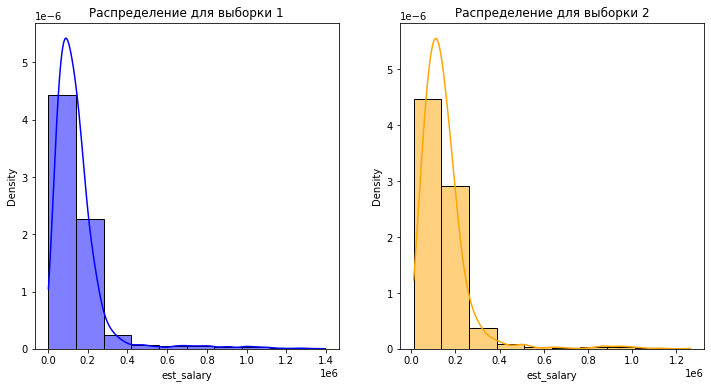

In [61]:
check_samples(income_loyal, income_churned)

В выборках есть выбросы, также не выполнены два критерия - равномерность и равенство дисперсий. В данном случае t-test не применим.

Для проверки гипотезы будем использовать U-тест Манна-Уитни.

U тест Манна-Уитни является непараметрическим методом, используемым для сравнения двух независимых выборок. Он применяется, когда данные не соответствуют нормальному распределению.

Показания для применения:
* Сравнение двух независимых групп, когда данные не нормальны
* Анализ данных, собранных по порядковым шкалам
* Исследования, где присутствуют выбросы, которые могут повлиять на результаты

Ограничения
* Не подходит для зависимых выборок (например, парные наблюдения).
* Не дает информации о том, насколько значительны различия между группами.
* Требует, чтобы выборки были независимыми друг от друга.

Плюсы U теста Манна-Уитни:
* Не требует нормальности распределения
* Подходит для непрерывных данных
* Устойчив к выбросам
* Простота в интерпретации

Минусы U теста Манна-Уитни:
* Менее мощный, чем параметрические тесты
* Не подходит для зависимых выборок
* Не дает информации о величине эффекта

Сформулируем гипотезы:
* **Нулевая гипотеза ($H_0$):** Средние доходы клиентов склонных и не склонных к оттоку РАВНЫ
* **Альтернативная гипотеза ($H_1$):** Средние доходы клиентов склонных и не склонных к оттоку НЕ РАВНЫ

Зададим пороговое значение alpha:

In [62]:
alpha = 0.05

Проведем U-тест Манна-Уитни:

In [63]:
income_stat, income_p_value = mannwhitneyu(income_loyal, income_churned)

print(f'Средний доход лояльных клиентов: {income_loyal.mean():.2f}')
print(f'Средний доход клиентов склонных к оттоку: {income_churned.mean():.2f}')
print()

print(f'Статистика U-теста: {income_stat}')
print(f'p-value: {income_p_value}')
print()

if income_p_value < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Нет оснований отвергнуть нулевую гипотезу")

Средний доход лояльных клиентов: 147783.20
Средний доход клиентов склонных к оттоку: 148243.01

Статистика U-теста: 7035119.0
p-value: 0.000243559272811695

Отвергаем нулевую гипотезу


Тест показал, что есть статистически значимая разница между доходами клиентов, которые склонны к оттоку и которые не склонны к оттоку. Таким образом подтвердилась гипотеза о различии в доходох клиентов по группам отточности.

Для сравнения результов, проведем также t-тест для выборок с неравными дисперсиями:

In [64]:
t_stat, p_value_t = stats.ttest_ind(income_loyal, income_churned, equal_var=False)

print(f'Средний доход лояльных клиентов: {income_loyal.mean():.2f}')
print(f'Средний доход клиентов склонных к оттоку: {income_churned.mean():.2f}')
print()

print(f'Статистика t-теста: {t_stat}')
print(f'p-value: {p_value_t}')
print()

if p_value_t < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Нет оснований отвергнуть нулевую гипотезу")

Средний доход лояльных клиентов: 147783.20
Средний доход клиентов склонных к оттоку: 148243.01

Статистика t-теста: -0.13995425426886435
p-value: 0.8887054822123845

Нет оснований отвергнуть нулевую гипотезу


Получили противоположный результат - данный тест показал отсутствие статистически значимой разницы между доходами клиентов по группам отточности. С учетом ранее обнаруженных противопоказаний к применению t-теста, ориентироваться будем на результаты U-теста.

### Проверка гипотезы о равенстве возраста клиентов мужчин и клиентов женщин

Создадим выборки возрастов клиентов в разбивке по полу:

In [65]:
f_age = df.query('gender_Ж==1')['age']
m_age = df.query('gender_М==1')['age']

Проверим данные выборки на соответствие ограничениям применения t-теста:

Размер 1-й выборки: 4995
Размер 2-й выборки: 5005
[V] За счет количества данных превышающее 30 наблюдений нормальность выборок не приниципиальна
[V] Размер выборок достаточно большой
[X] Одна или обе выборки распределены неравномерно
[X] Дисперсии не равны


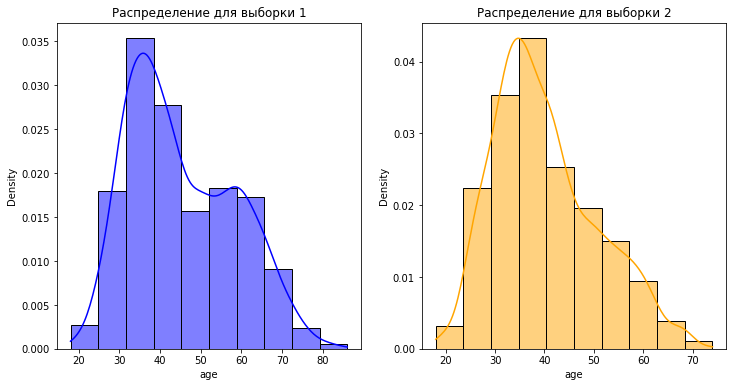

In [66]:
check_samples(f_age, m_age)

Для данной гипотезы также будем использовать U-тест Манна-Уитни, так как не выполнены два ограничивающих критерия применения t-теста - равномерность распределения выборок и равенство дисперсий.

Сформулируем гипотезы:
* **Нулевая гипотеза ($H_0$):** Средний возраст клиентов мужчин и средний возраст клиентов женщин РАВЕН
* **Альтернативная гипотеза ($H_1$):** Средний возраст клиентов мужчин и средний возраст клиентов женщин НЕ РАВЕН

Проведем U-тест Манна-Уитни:

In [67]:
age_stat, age_p_value = mannwhitneyu(f_age, m_age)

print(f'Средний возраст женщин: {f_age.mean():.2f}')
print(f'Средний возраст мужчин: {m_age.mean():.2f}')
print()

print(f'Статистика U-теста: {age_stat}')
print(f'p-value: {age_p_value}')
print()

if age_p_value < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Нет оснований отвергнуть нулевую гипотезу")

Средний возраст женщин: 45.32
Средний возраст мужчин: 40.14

Статистика U-теста: 15237397.0
p-value: 2.93049135501137e-80

Отвергаем нулевую гипотезу


Тест показал, что есть статистически значимая разница между возрастом клиентов женщин и клиентов мужчин. Таким образом гипотеза об отсутствии различий в возрасте клиентов по полу не подтвердилась.

### Проверка гипотезы о более высоких доходах владельцев кредитных карт по сравнению с клиентами без кредитных карт

Создадим выборки доходов клиентов в разбивке по признаку владения кредитной картой:

In [68]:
сс_owner = df.query('credit_card==1')['est_salary']
cc_not_owner = df.query('credit_card==0')['est_salary']

Проверим данные выборки на соответствие ограничениям применения t-теста:

Размер 1-й выборки: 6804
Размер 2-й выборки: 3196
[V] За счет количества данных превышающее 30 наблюдений нормальность выборок не приниципиальна
[V] Размер выборок достаточно большой
[X] Одна или обе выборки распределены неравномерно
[X] Дисперсии не равны


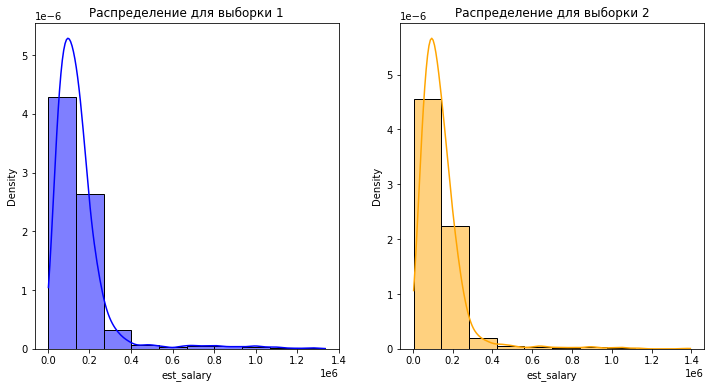

In [69]:
check_samples(сс_owner, cc_not_owner)

Для проверки данной гипотезы также будем использоват U-тест Манна-Уитни.

Сформулируем гипотезы:

* **Нулевая гипотеза ($H_0$):** Средний доход владельцев кредитных карт равен среднему доходу клиентов без кредитных карт
* **Альтернативная гипотеза ($H_1$):** Средний доход владельцев кредитных карт больше, чем средний доход клиентов без кредитных карт

Проведем U-тест Манна-Уитни:

In [70]:
сс_stat, сс_p_value = mannwhitneyu(сс_owner, cc_not_owner, alternative='greater')

print(f'Средний доход владельцев к/карт: {сс_owner.mean():.2f}')
print(f'Средний доход клиентов без к/карт: {cc_not_owner.mean():.2f}')
print()

print(f'Статистика U-теста: {сс_stat}')
print(f'p-value: {сс_p_value}')
print()

if сс_p_value < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Нет оснований отвергнуть нулевую гипотезу")

Средний доход владельцев к/карт: 151263.44
Средний доход клиентов без к/карт: 140635.93

Статистика U-теста: 11183959.5
p-value: 0.010405121816696747

Отвергаем нулевую гипотезу


Получили статистически значимую разницу между доходами клиентов с кредитными картами и без кредитных карт. Таким образом, гипотеза о  более высоких доходов владельцев кредитных карт по сравнению с клиентами без кредитных карт подтвердилась.

### Выводы по разделу проверки гипотез

**Гипотеза о различии доходов между клиентами, которые склонны и не склонны к уходу из Банка**
* В выборках для теста есть существенные выбросы, не выполнены три критерия ограничивающих применение t-теста - равномерность и равенство дисперсий, отсутствие выбросов
* Для проверки гипотезы использован U-тест Манна-Уитни.
* Тест показал, что есть статистически значимая разница между доходами клиентов, которые склонны к оттоку и которые не склонны к оттоку. 
* Подтвердилась гипотеза о различии в доходох клиентов по группам отточности.

**Проверка гипотезы о равенстве возраста клиентов мужчин и клиентов женщин**
* Для данной гипотезы также будем использован U-тест Манна-Уитни, так как не выполнены два ограничивающих критерия применения t-теста - равномерность распределения выборок и равенство дисперсий.
* Тест показал, что есть статистически значимая разница между возрастом клиентов женщин и клиентов мужчин. 
* Гипотеза об отсутствии различий в возрасте клиентов по полу не подтвердилась.

**Проверка гипотезы о более высоких доходах владельцев кредитных карт по сравнению с клиентами без кредитных карт**
* Для данной гипотезы использован U-тест Манна-Уитни, так как не выполнены три ограничивающих критерия применения t-теста - равномерность распределения выборок и равенство дисперсий, отсутствие выбросов
* Тест показал, что есть статистически значимая разница между доходами клиентов с кредитными картами и без кредитных карт. 
* Гипотеза о более высоких доходов владельцев кредитных карт по сравнению с клиентами без кредитных карт подтвердилась.

## Подведение промежуточных итогов

На основе проведенного исследовательского анализа данных, анализа корреляций и средних значений признаков в разрезе групп отточности, предлагается выделить основные признаки для сегментирования клиентов:
    
* Наличие кредитной карты
* Возраст клиентов
* Активность
* Количество баллов собственности

Сформируем следующий сегмент для охвата клиентов склонных к оттоку:
* Клиенты без кредитных карт
* Клиенты моложе 41 года
* Клиенты активно пользующиеся личным кабинетом
* Клиенты имеющие более трех баллов собственности

Создавать сложные сегменты не будем, так как при пересечении условий, существенно сокращается группа целевых клиентов.

Сегмент **"клиенты без кредитных карт"** и количество целевых клиентов:

In [132]:
segment_by_credit_card = df.query('credit_card==0')

segment_by_credit_card.groupby('churn')['credit_card'].count()

churn
0    2374
1     815
Name: credit_card, dtype: int64

В сегменте клиентов без кредитной карты оказалось 815 целевых клиентов, склонных к оттоку. С такими клиентами необходимо работать в направлении оформления кредитной карты (разумеется с учетом возможных рисков и платежеспособности клиента).

Сегмент **"клиенты моложе 41 года"** и количество целевых клиентов:

In [133]:
segment_by_age = df.query('age<=41')

segment_by_age.groupby('churn')['credit_card'].count()

churn
0    4361
1    1041
Name: credit_card, dtype: int64

В данном сегменте оказалось более 1000 целевых клиентов. С учетом молодого возраста клиентов необходимо подбирать специальные предложения с учетом интересов данной возрастной категории. 

Для данной группы можно предложить следующий набор опций:
* Молодежные кредитны карты с пониженной процентной ставкой и бесплатным обслуживанием
* Кредиты на образование
* Повышенный кэшбэк на категории развлечений, путешествий, образования

Также необходимо повышать удобство работы с мобильным приложением, так как клиенты данной возрастной категории как правило активно пользуются мобильным банком - можно добавить функционал покупки билетов в кино и на другие события (концерты, театр, стендап и т.д.), возможность бронирования гостиниц и авиа/жд билетов.

Сегмент **"активные клиенты"** и количество целевых клиентов:

In [134]:
segment_by_activity = df.query('last_activity==1')

segment_by_activity.groupby('churn')['credit_card'].count()

churn
0    3938
1    1277
Name: credit_card, dtype: int64

В данном сегменте оказалось 1277 целевых клиентов. С учетом того, что в данную группу попали те, кто регулярно заходит в мобильны банк / личный кабинет, для повышения лояльности данной группы необходимо работать над качествоим, надежностью и удобством мобильного приложения, возможно делать из него "суперап", то есть приложение, где в одном месте можно решать большинство повседневных задач связанных с платежами - оплата коммунальных услуг, образовательных услуг для детей, удобное управление счетами и вкладами, бронирование гостиниц и билетов и т.д.

Сегмент **"клиенты имеющие более 3-х баллов собственности"** и количество целевых клиентов:

In [135]:
segment3 = df.query('equity>3')

segment3.groupby('churn')['credit_card'].count()

churn
0    2885
1    1148
Name: credit_card, dtype: int64

В данном сегменте получили более 1100 целевых клиентов. Для данной группы с учетом значительного количества собственности для удержания таких клиентов можно предложить специальные условия страхования недвижимости (от пожара, затопления и т.д.), особые тарифы на страхование транспортных средств, пакетные предложения охватывающие все объекты собственности с существенной скидкой. Также можно рассмотреть возможность предложения таким клиентам премиального пакета обслуживания без дополнительной платы (прописать условия по доходу, остаткам на счетах, использованию страховых программ для максимального охвата данной категории и повышению вероятности акцепта клиента)

### Выводы по промежуточным итогам

На основе исследованных признаков клиентов Банка предложены следующие сегменты для таргетированной работы по снижению количества пользователей, склонных к оттоку:
* **"Клиенты без кредитных карт"**
    * В сегменте клиентов без кредитной карты оказалось 815 целевых клиентов, склонных к оттоку. С такими клиентами необходимо работать в направлении оформления кредитной карты (разумеется с учетом возможных рисков и платежеспособности клиента).

* **"Клиенты моложе 41 года"**
    * В данном сегменте оказалось более 1000 целевых клиентов. С учетом молодого возраста клиентов необходимо подбирать специальные предложения с учетом интересов данной возрастной категории. 
    * Для данной группы можно предложить следующий набор опций:
        * Молодежные кредитны карты с пониженной процентной ставкой и бесплатным обслуживанием
        * Кредиты на образование
        * Повышенный кэшбэк на категории развлечений, путешествий, образования
    * Также необходимо повышать удобство работы с мобильным приложением, так как клиенты данной возрастной категории как правило активно пользуются мобильным банком - можно добавить функционал покупки билетов в кино и на другие события (концерты, театр, стендап и т.д.), возможность бронирования гостиниц и авиа/жд билетов.

* **"Активные клиенты"**
* В данном сегменте оказалось 1277 целевых клиентов. 
* С учетом того, что в данную группу попали те, кто регулярно заходит в мобильны банк / личный кабинет, для повышения лояльности данной группы необходимо работать над качествоим, надежностью и удобством мобильного приложения, возможно делать из него "суперап", то есть приложение, где в одном месте можно решать большинство повседневных задач связанных с платежами - оплата коммунальных услуг, образовательных услуг для детей, удобное управление счетами и вкладами, бронирование гостиниц и билетов и т.д.


* **"Клиенты имеющие более 3-х баллов собственности"**
* В данном сегменте получили более 1100 целевых клиентов. Для данной группы с учетом значительного количества собственности для удержания таких клиентов можно предложить специальные условия страхования недвижимости (от пожара, затопления и т.д.), особые тарифы на страхование транспортных средств, пакетные предложения охватывающие все объекты собственности с существенной скидкой. Также можно рассмотреть возможность предложения таким клиентам премиального пакета обслуживания без дополнительной платы (прописать условия по доходу, остаткам на счетах, использованию страховых программ для максимального охвата данной категории и повышению вероятности акцепта клиента)

Более тонкая настройка сегментов клиентов, основанная на явных и неявных связях в данных может быть получена с использованием инструментов машинного обучения.

## Сегментация пользователей банка

Задачи данного раздела:
* Выявить основные сегменты клиентов
* Проанализровать полученные сегменты
* Выбрать сегменты наиболее перспективные с точки зрения снижения отточности клиентов

Для задачи кластеризации клиентов можно использовать следующие популярные алгоритмы:

* **K-Means**
    * Описание: Разбивает данные на k кластеров, минимизируя сумму квадратов расстояний от каждой точки до центра её кластера.
    * Плюсы: Простой, быстрый, хорошо масштабируется на большие наборы данных.
    * Минусы: Требует задать количество кластеров (k) заранее, чувствителен к выбросам и начальному расположению центроидов, предполагает сферическую форму кластеров.

* **Агломеративная иерархическая кластеризация**
    * Описание: Строит иерархию кластеров, объединяя или разделяя их на основе расстояния между ними. Может быть агломеративной (объединяющей) или дивизимной (разделяющей).
    * Плюсы: Позволяет визуализировать иерархию кластеров с помощью дендрограммы, не требует заранее задавать количество кластеров (хотя нужно определить критерий остановки).
    * Минусы: Вычислительно затратен для больших наборов данных.
    

Сначала построим дендрограмму на основе матрицы расстояний полученной методом `linkage()`, а затем обучим модель кластеризации на основании алгоритма K-means.

Метод `linkage()` используется в библиотеке SciPy для иерархической кластеризации данных. Он позволяет объединять объекты в кластеры на основе расстояний между ними. Метод принимает в качестве входных данных матрицу расстояний или набор данных и возвращает иерархическую структуру, которая может быть использована для построения дендрограммы.

### Определение количества сегментов пользователей Банка методом иерархической кластеризации

Для получения матрицы расстояний методу `linkage()` на вход обязательно подавать стандартизированные данные. Создадим объект класса StandardScaler:

In [136]:
scaler = StandardScaler()

Стандартизируем признаки нашего датасета:

In [137]:
X = scaler.fit_transform(df)

Получим матрицу расстояний:

In [138]:
linked = linkage(X, method = 'ward')

Построим дендрограммму:

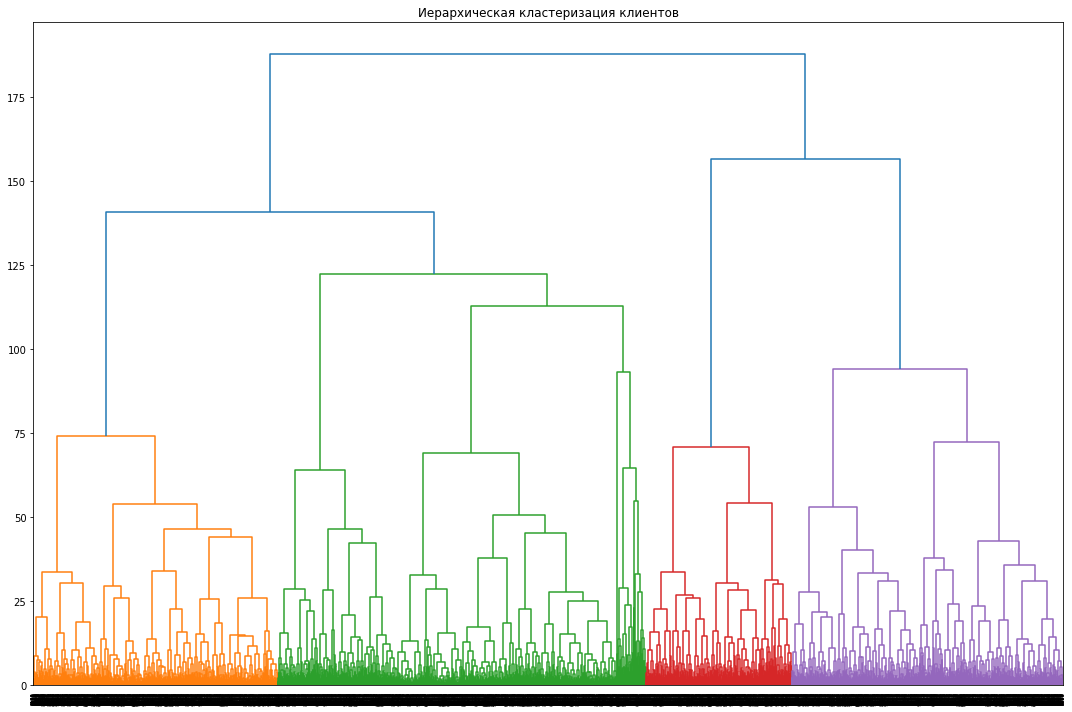

In [139]:
plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top')
plt.title('Иерархическая кластеризация клиентов')
plt.tight_layout()
plt.show()

Получили 4 кластера. Используем эту информацию для обучения модели кластеризации на основании алгоритма K-means.

### Кластеризация клиентов с использованием алгоритма K-Means

Инициализируем модель K-Means c 4 кластерами и random_state=42 для воспроизводимости результатов:

In [140]:
km = KMeans(n_clusters=4, random_state=42)

Применяем алгоритм к данным и cформируем вектор меток кластеров:

In [141]:
labels = km.fit_predict(X)

Добавим метки кластеров к исходному датасету и проверим результат:

In [142]:
df_uncoded['claster'] = labels
df_uncoded.head()

,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,city,gender,claster
0,850,25,1,59214.82,2,0,1,75719.14,1,Рыбинск,Ж,2
1,861,37,5,850594.33,3,1,0,86621.77,0,Рыбинск,Ж,2
2,892,30,0,127337.41,1,1,1,107683.34,0,Рыбинск,Ж,2
3,866,51,5,1524746.26,2,0,1,174423.53,1,Ярославль,Ж,3
4,730,34,5,174.00,1,1,0,67353.16,1,Ярославль,М,1


Метрика силуэта — это метод оценки качества кластеризации, который позволяет определить, насколько хорошо объекты сгруппированы в кластеры. Она измеряет, насколько близки объекты внутри одного кластера по сравнению с объектами из других кластеров.

Метрика силуэта для каждого объекта рассчитывается по следующей формуле:
$$s_i=\frac{b_i-a_i}{max(a_i, b_i)}$$
где:
* $s_i$ — значение силуэта для объекта i.
* $a_i$ — среднее расстояние от объекта i до всех других объектов в том же кластере (внутреннее расстояние).
* $b_i$ — минимальное среднее расстояние от объекта i до объектов в ближайшем другом кластере (внешнее расстояние).

Значения метрики силуэта варьируются от -1 до 1:
* Значение близкое к 1 указывает на то, что объект хорошо кластеризован, так как он ближе к другим объектам своего кластера, чем к объектам других кластеров.
* Значение около 0 указывает на то, что объект находится на границе между двумя кластерами.
* Отрицательное значение указывает на то, что объект, вероятно, был неправильно отнесен к своему кластеру, так как он ближе к объектам другого кластера.


Посчитаем метрику силуэта:

In [143]:
silhouette_score(X, labels)

0.1929349004497338

Метрика силуэта больше 0, кластеры приемлемо отделяются друг от друга.

### Анализ полученных сегментов

Проверим как полученные кластеры отличаются по оттоку:

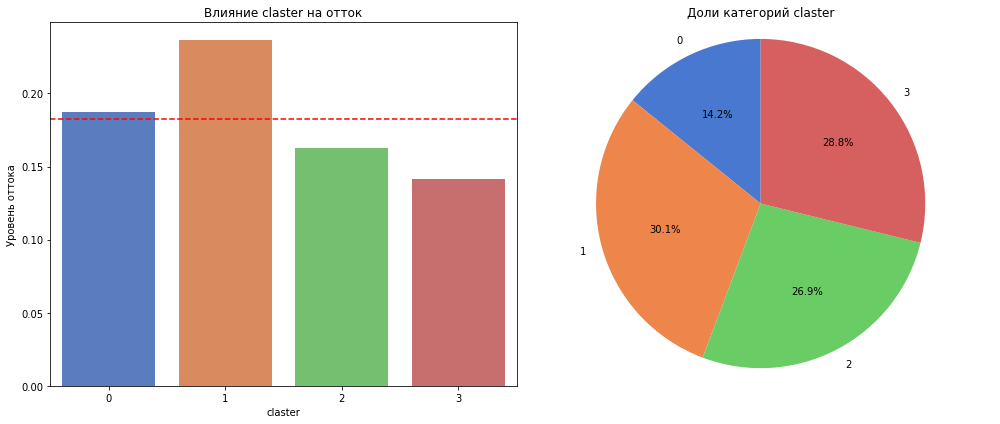

In [144]:
describe_feature(data=df_uncoded,
                 kind='categorical',
                 feature='claster',
                 hue='churn')

* Получили относительно равномерное распределение кластеров, самый малочисленный кластер - 0 (14% пользователей).
* Отток кластера 0 получился на уровне среднего по всем клиентам.
* Самый лояльный кластер - 3-й, отток у 2-го кластера также ниже среднего уровня.
* У кластера 1 получился самый высокий уровень оттока, значительно выше среднего.

Таким образом для целей снижения оттока клиентов необходимо понять характеристики клиентов из кластера 1.

Проверим как полученные кластеры отличаются по непрерывным признакам:

In [145]:
df_uncoded.pivot_table(index='claster',
                       values=['score', 'age', 'balance', 'est_salary'],
                       aggfunc=['mean', 'median'])

mean                             median                           
          age   balance est_salary  score    age   balance est_salary score
claster                                                                    
0       44.14 573413.83  111518.46 842.64     42 406461.94  100059.38   841
1       39.73 815105.10  174994.54 851.54     38 346869.20  138455.81   859
2       43.31 588298.36  134816.22 848.56     41 371858.35  113335.90   853
3       44.62 636893.92  149410.54 848.76     42 398268.14  119255.25   853

* **Возраст**
    * В нашем целевом кластере клиентов склонных к оттоку (кластер 1) находятся самые молодые клиенты - средний возраст около 40 лет, медианный - 38.
    * В кластер 0 с оттоком на уровне среднего средний возраст клиента 44 года, медианный 42.
    * В кластере 3 с самым низким уровнем оттока находятся самые взрослые клиенты - средний возраст около 45 лет, медианный - 42.
    * В кластере 2 уровень оттока немного выше чем в 3-м кластере, но ниже среднего уровня, а клиенты немного моложе, чем в 3-м кластере - средний возраст 43 года, медианный 41.

* **Доход**
    * Самый высокий средний доход у клиентов в кластере 1, медианный доход также выше, чем в остальных кластерах
    * Самый низкий доходод у клиентов из кластера 0
    * На втором месте по доходу клиенты из кластера 3 (самые лояльные)

* **Баланс**
    * Самые высокие средние накопления также у клиентов из кластера 1, а медианные накопления выше в кластере 0 и при этом, в этом же кластере средние накопления самые низкие.

* **Кредитный скорринг**
    * Баллы кредитного скорринга отличаются несущественно между кластерами, но у кластера 1 средний и медианный скорринг выше чем в остальных кластерах.

Проверим как полученные кластеры отличаются по дискретным признакам:

In [146]:
df_uncoded.pivot_table(index='claster',
                       values=['equity', 'products'],
                       aggfunc='median')

,equity,products
claster,,
0,3,2
1,3,2
2,3,2
3,3,2


По медианному количеству собственности и количеству используемых продуктов все 4 кластера получились идентичными.

Проверим как полученные кластеры отличаются по бинарным категориальным признакам:

In [147]:
df_uncoded.pivot_table(index='claster',
                       values=['credit_card', 'last_activity'],
                       aggfunc='mean')

,credit_card,last_activity
claster,,
0,0.57,0.53
1,0.79,0.50
2,0.64,0.56
3,0.66,0.51


* **Наличие кредитной карты**
* В кластере 1 (клиенты с самым высоким оттоком) - больше всего владельцев кредитных карт - 79% клиентов

* **Активность**
* По активности клиенты между кластерами отличаются несущественно, средний уровень активных клиентов находится 0.5-0.56.
* Самый неактивный кластер - первый (0.50), самый активный - второй (0.56)

В данном случае распределение клиентов по кластерам и обнаруженные ранее закономерности поведения клиентов склонных и не склонных к оттоку разошлись. В предыдущих разделах мы выяснили, что клиенты активно пользующиеся мобильным банком / личным кабинетом и не имеющие кредитной карты более всего склонны к оттоку.

Проверим распределение кластеров по городам:

In [148]:
df_uncoded.pivot_table(index='claster',
                       columns='city',
                       values='churn',
                       aggfunc='count')

city,Ростов,Рыбинск,Ярославль
claster,,,
0,1416.00,NaN,NaN
1,NaN,NaN,2999.00
2,NaN,2682.00,NaN
3,NaN,NaN,2876.00


* Здесь получили интересное распределение - кластер 0 (с оттоком на уровне среднего по банку) полностью состоит из клиентов из Ростова, он же самый малочисленный - 1416 клиентов.

* Кластер 2 полностью состоит из клиентов проживающих в Рыбинске (отток ниже среднего, но выше чем в 3-м кластере).

* Из жителей Ярославля составлены 2 кластера почти одинакового размера:
    * Кластер 1 (наиболее склонные к оттоку) - 2999 клиентов
    * Кластер 3 (наиболее лояльные клиенты) - 2876 клиентов

Проверим распределение кластеров по полу:

In [149]:
df_uncoded.pivot_table(index='claster',
                       columns='gender',
                       values='churn',
                       aggfunc='count')

gender,Ж,М
claster,,
0,733.00,683.00
1,NaN,2999.00
2,1373.00,1309.00
3,2876.00,NaN


* Тут также получили не менее интересное распределение - алгоритм разделил два Ярославских кластера по полу:
    * Самый лояльный сегмент 3 состоит полностью из женщин проживающих в Ярославле
    * Сегмент 1 наиболее склонный к оттоку полностью состоит из мужчин проживающих в Ярославле

* В остальных кластерах клиенты по полу распределены достаточно равномерно.

Посмотрим подробно на распределение данных внутри каждого кластера по ключевым признакам - возраст, доход, баланс, наличие кредитной карты, активность, пол

#### Кластер 0 - жители Ростова

Сделаем срез по клиентам из нулевого кластера:

In [150]:
claster0 = df_uncoded.query('claster==0')

Рассмотри распределение по возрасту:

Min: 18
Max: 83
Среднее: 44.14
Медиана: 42.00
Ст. откл-е: 12.73


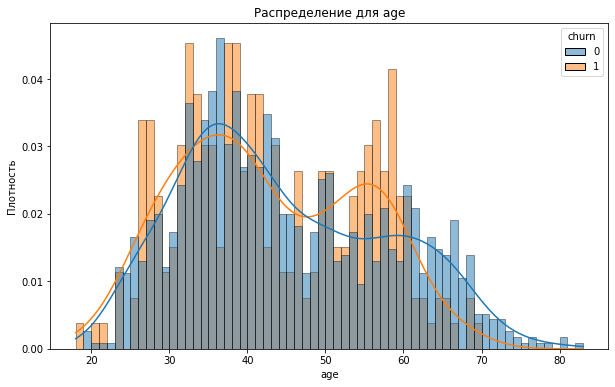

In [151]:
describe_feature(data=claster0,
                 kind='continuous',
                 feature='age',
                 hue='churn')

Наблюдается два пика - пользователи в возрасте 38-40 лет и пользователи в возрасте 55-60. Высокая отточность в группе 55-60 лет, до 30 и около 40. Средний возраст клиентов в кластере 44 года, медианный - 42, за счет длинного "хвоста" справа.

Распределение накоплений:

In [152]:
print(f"Min: {claster0['balance'].min()}")
print(f"Max: {claster0['balance'].max()}")
print(f"Среднее: {claster0['balance'].mean():.2f}")
print(f"Медиана: {claster0['balance'].median():.2f}")
print(f"Ст. откл-е: {claster0['balance'].std():.2f}")

fig = px.histogram(
    claster0,
    x='balance',
    color='churn',
    barmode='overlay',
    histnorm='probability',
    labels={'churn': 'Churn'},
    title='Распределение для признака balance',
    opacity=0.5,
    nbins=20
)

# Update layout
fig.update_layout(
    xaxis_title='Balance',
    yaxis_title='Плотность',
    legend_title='Churn'
)

# Show the plot
fig.show()

Min: 22.0
Max: 11834882.67
Среднее: 573413.83
Медиана: 406461.94
Ст. откл-е: 637647.96


Средние накопления клиента в данном кластере - 573 тыс. руб., медианные - 406 тыс. руб. У большей части клиентов данного кластера накопления не превышают 1.5 млн руб. Есть небольшое количество клиентов с накоплениями более 2.5 млн руб. У клиентов с низкими накоплениями (менее 500 тыс. руб) склонность к оттоку ниже.

Распределение доходов в кластере 0:

In [153]:
print(f"Min: {claster0['est_salary'].min()}")
print(f"Max: {claster0['est_salary'].max()}")
print(f"Среднее: {claster0['est_salary'].mean():.2f}")
print(f"Медиана: {claster0['est_salary'].median():.2f}")
print(f"Ст. откл-е: {claster0['est_salary'].std():.2f}")

fig = px.histogram(
    claster0,
    x='est_salary',
    color='churn',
    barmode='overlay',
    histnorm='probability',
    labels={'churn': 'Churn'},
    title='Распределение для признака est_salary',
    opacity=0.5,
    nbins=50
)

# Update layout
fig.update_layout(
    xaxis_title='Salary',
    yaxis_title='Плотность',
    legend_title='Churn'
)

# Show the plot
fig.show()

Min: 5341.5
Max: 507039.17
Среднее: 111518.46
Медиана: 100059.38
Ст. откл-е: 69712.59


Средняя зарплата в кластере 0 - 112 тыс. руб., мендианная - 100 тыс. руб. Есть длинный хвост с зарплатами более 240 тыс. руб. Основная часть клиентов из этого кластера получает доход 20-240 тыс. руб.

Распределение по количеству используемых продуктов:

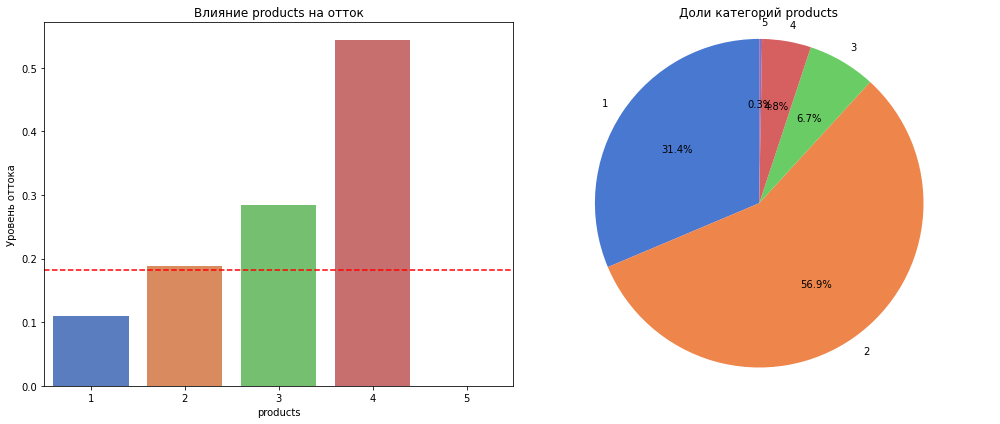

In [154]:
describe_feature(data=claster0,
                 kind='categorical',
                 feature='products',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

Более половины клиентов пользуется двумя продуктами. Следующая по величине группа клиентов - те, кто пользуется только одним продуктом. Самые лояльные клиенты те, что пользуются одним продуктом. Наиболее склонные к оттоку клиенты с 3 и 4 продуктами (таких клиентов значительно меньше). У клиентов с двумя продуктами уровень оттока соответствует среднему уровню по Банку.

Распределение по вледению кредитной картой:

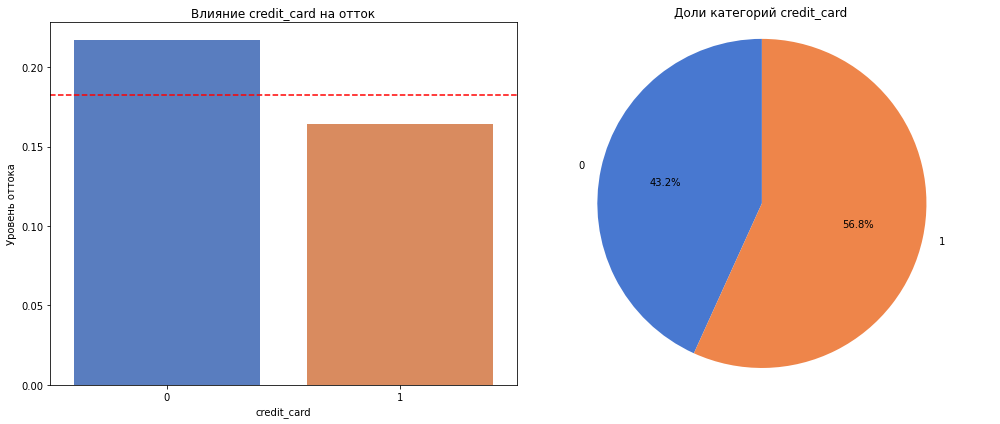

In [155]:
describe_feature(data=claster0,
                 kind='categorical',
                 feature='credit_card',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

У клиентов без кредитной карты отток выше среднего уровня - таких клиентов 43%. У клиентов с кредитной картой отток ниже среднего уровня по Банку.

Распределение по активности:

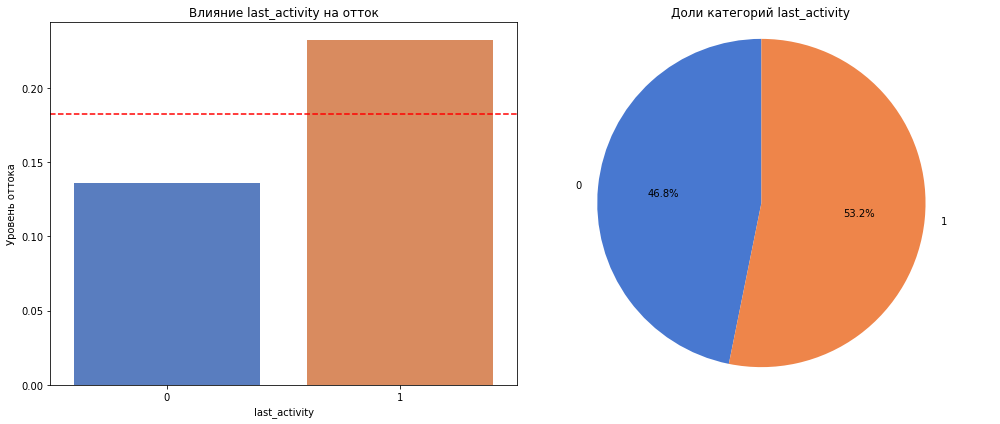

In [156]:
describe_feature(data=claster0,
                 kind='categorical',
                 feature='last_activity',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

У неактивных клиентов (их менее 47%) отток ниже среднего уровня. У активных (более половины клиентов в сегменте) - отток выше среднего.

Распределение по полу:

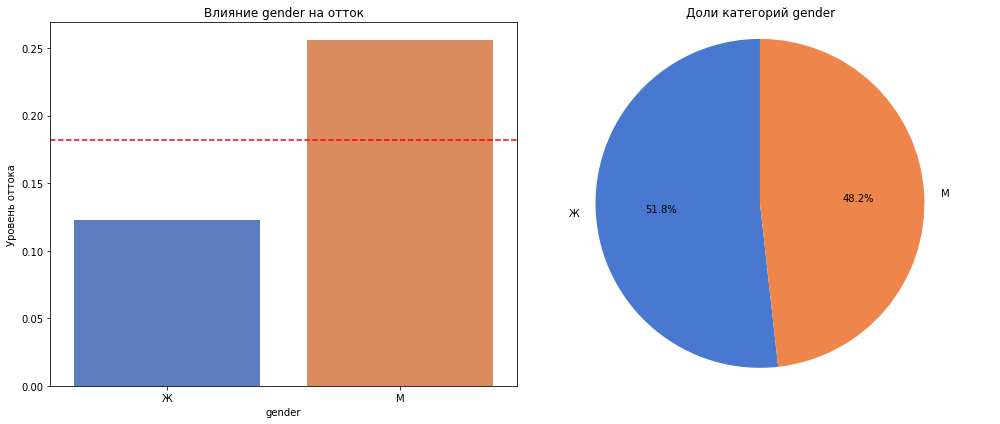

In [157]:
describe_feature(data=claster0,
                 kind='categorical',
                 feature='gender',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

Клиенты распределены по полу равномерно. Женщины менее склонны к оттоку, у мужчин уровень оттока выше среднего по Банку.

#### Кластер 3 - клиенты женского пола из Ярославля

Сделаем срез по клиентам из кластера 3:

In [158]:
claster3 = df_uncoded.query('claster==3')

Рассмотри распределение по возрасту:

Min: 18
Max: 86
Среднее: 44.62
Медиана: 42.00
Ст. откл-е: 12.94


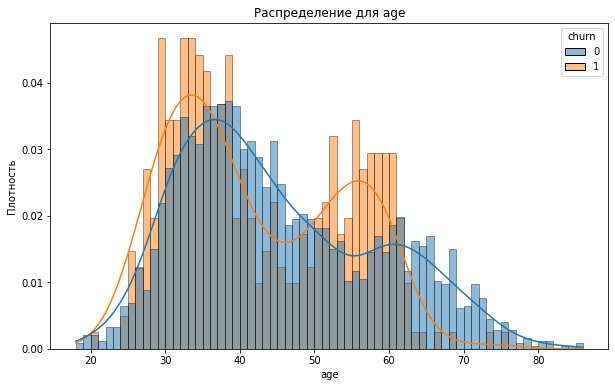

In [159]:
describe_feature(data=claster3,
                 kind='continuous',
                 feature='age',
                 hue='churn')

Средний возраст 45 лет. Два пика - 30-40 лет и 50-62 года. Высокая доля клиентов склонных к оттоку в промежутке 25-35 лет, а также 50-60 лет.

Распределение накоплений:

In [160]:
print(f"Min: {claster3['balance'].min()}")
print(f"Max: {claster3['balance'].max()}")
print(f"Среднее: {claster3['balance'].mean():.2f}")
print(f"Медиана: {claster3['balance'].median():.2f}")
print(f"Ст. откл-е: {claster3['balance'].std():.2f}")

fig = px.histogram(
    claster3,
    x='balance',
    color='churn',
    barmode='overlay',
    histnorm='probability',
    labels={'churn': 'Churn'},
    title='Распределение для признака balance',
    opacity=0.5,
    nbins=50
)

# Update layout
fig.update_layout(
    xaxis_title='Balance',
    yaxis_title='Плотность',
    legend_title='Churn'
)

# Show the plot
fig.show()

Min: 20.0
Max: 21549943.63
Среднее: 636893.92
Медиана: 398268.14
Ст. откл-е: 908308.36


Средние накопления 637 тыс.руб. Большая часть клиентов имеет накопления до 2.25 млн руб. Клиенты с накоплениями до 750 тыс. руб менее склонны к оттоку, чем клиенты с большими накоплениями.

Распределение доходов:

In [161]:
print(f"Min: {claster3['est_salary'].min()}")
print(f"Max: {claster3['est_salary'].max()}")
print(f"Среднее: {claster3['est_salary'].mean():.2f}")
print(f"Медиана: {claster3['est_salary'].median():.2f}")
print(f"Ст. откл-е: {claster3['est_salary'].std():.2f}")

fig = px.histogram(
    claster3,
    x='est_salary',
    color='churn',
    barmode='overlay',
    histnorm='probability',
    labels={'churn': 'Churn'},
    title='Распределение для признака est_salary',
    opacity=0.5,
    nbins=50
)

# Update layout
fig.update_layout(
    xaxis_title='Salary',
    yaxis_title='Плотность',
    legend_title='Churn'
)

# Show the plot
fig.show()

Min: 2546.3
Max: 1296838.08
Среднее: 149410.54
Медиана: 119255.25
Ст. откл-е: 148064.96


Средняя зарплата - 150 тыс. руб., Есть длинный хвост с зарплатами более 250 тыс. руб. Основная часть клиентов из этого кластера получает доход до 250 тыс. руб.

Распределение по количеству используемых продуктов:

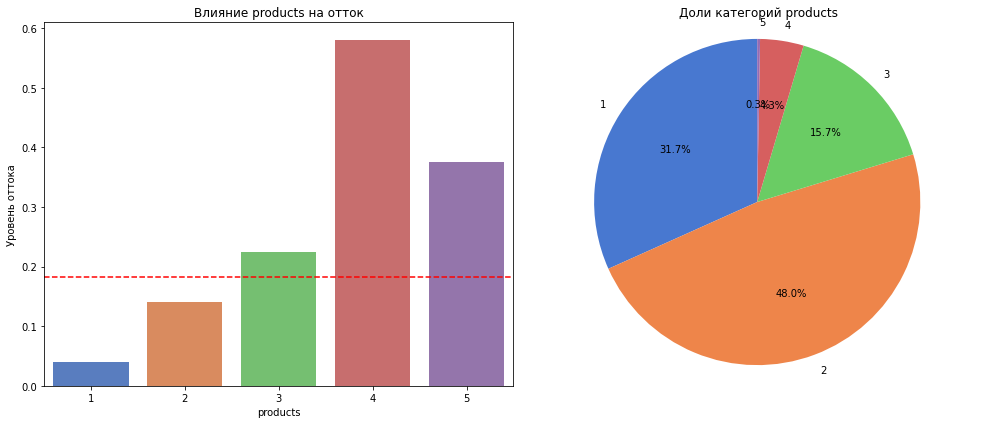

In [162]:
describe_feature(data=claster3,
                 kind='categorical',
                 feature='products',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

У клиентов использующих более 2 продуктов склонность к оттоку превышает средний уровень по банку. В основном клиенты пользуются одним или двумя продуктами.

Распределение по вледению кредитной картой:

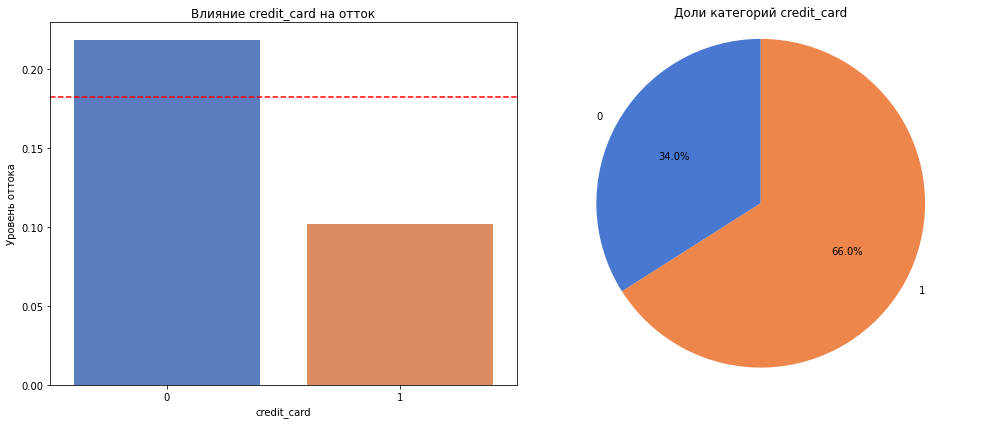

In [163]:
describe_feature(data=claster3,
                 kind='categorical',
                 feature='credit_card',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

66% клиентов имеют кредитную карту, уровень их склонности к оттоку ниже среднего. У клиентов без кредитных карт уровень оттока превышает средний по банку.

Распределение по активности:

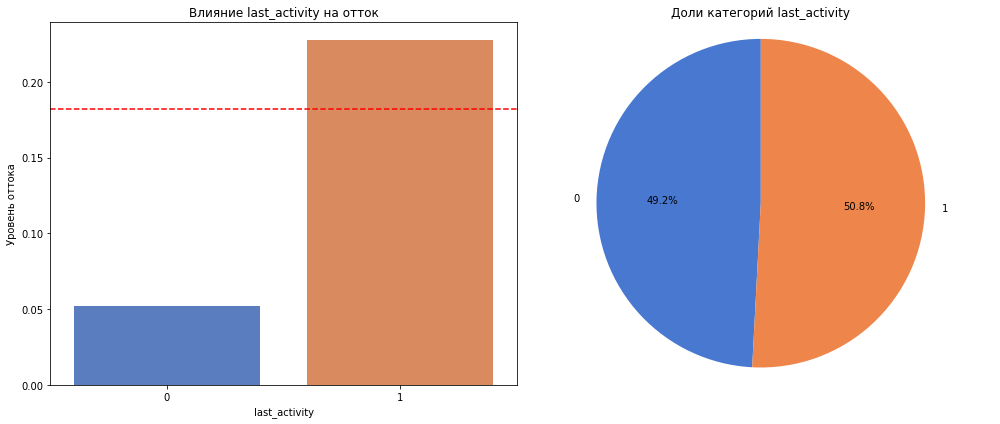

In [164]:
describe_feature(data=claster3,
                 kind='categorical',
                 feature='last_activity',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

Доли активных и неактивных пользователей сопоставимы, у неактивных пользователей склонность к оттоку значительно ниже среднего уровня по банку, а у активных пользователей выше.

#### Кластер 1 - клиенты мужского пола из Ярославля

Сделаем срез по клиентам из кластера 1:

In [165]:
claster1 = df_uncoded.query('claster==1')

Рассмотри распределение по возрасту:

Min: 18
Max: 74
Среднее: 39.73
Медиана: 38.00
Ст. откл-е: 10.29


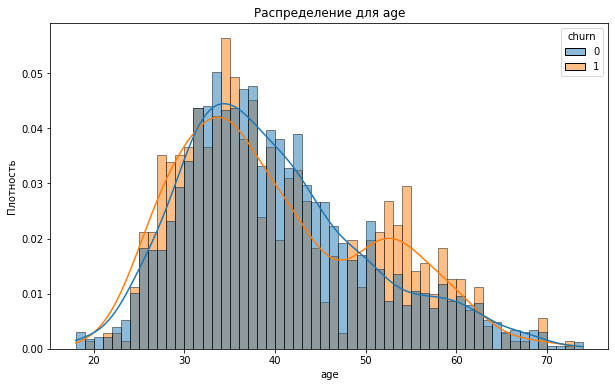

In [166]:
describe_feature(data=claster1,
                 kind='continuous',
                 feature='age',
                 hue='churn')

Средний возраст 40 лет. Два пика - 25-45 лет и 50-55 лет. Высокая доля клиентов склонных к оттоку в промежутке 25-30 лет, 35 лет, а также 52-60 лет.

Распределение накоплений:

In [167]:
print(f"Min: {claster1['balance'].min()}")
print(f"Max: {claster1['balance'].max()}")
print(f"Среднее: {claster1['balance'].mean():.2f}")
print(f"Медиана: {claster1['balance'].median():.2f}")
print(f"Ст. откл-е: {claster1['balance'].std():.2f}")

fig = px.histogram(
    claster1,
    x='balance',
    color='churn',
    barmode='overlay',
    histnorm='probability',
    labels={'churn': 'Churn'},
    title='Распределение для признака balance',
    opacity=0.5,
    nbins=50
)

# Update layout
fig.update_layout(
    xaxis_title='Balance',
    yaxis_title='Плотность',
    legend_title='Churn'
)

# Show the plot
fig.show()

Min: 0.0
Max: 119113552.01
Среднее: 815105.10
Медиана: 346869.20
Ст. откл-е: 2983592.60


Средние накопления 815 тыс.руб., медианные - 347 тыс. руб. Большая часть клиентов имеет накопления до 2.5 млн руб. Есть небольшое количество клиентов с очень высоким уровнем накоплений (более 7.5 млн рублей). Клиенты с накоплениями до 2.5 млн руб менее склонны к оттоку, чем клиенты с большими накоплениями.

Распределение доходов:

In [168]:
print(f"Min: {claster1['est_salary'].min()}")
print(f"Max: {claster1['est_salary'].max()}")
print(f"Среднее: {claster1['est_salary'].mean():.2f}")
print(f"Медиана: {claster1['est_salary'].median():.2f}")
print(f"Ст. откл-е: {claster1['est_salary'].std():.2f}")

fig = px.histogram(
    claster1,
    x='est_salary',
    color='churn',
    barmode='overlay',
    histnorm='probability',
    labels={'churn': 'Churn'},
    title='Распределение для признака est_salary',
    opacity=0.5,
    nbins=50
)

# Update layout
fig.update_layout(
    xaxis_title='Salary',
    yaxis_title='Плотность',
    legend_title='Churn'
)

# Show the plot
fig.show()

Min: 10010.35
Max: 1395064.45
Среднее: 174994.54
Медиана: 138455.81
Ст. откл-е: 171360.69


Средняя зарплата - 175 тыс. руб., Есть длинный хвост с зарплатами более 300 тыс. руб. Основная часть клиентов из этого кластера получает доход до 300 тыс. руб.

Распределение по количеству используемых продуктов:

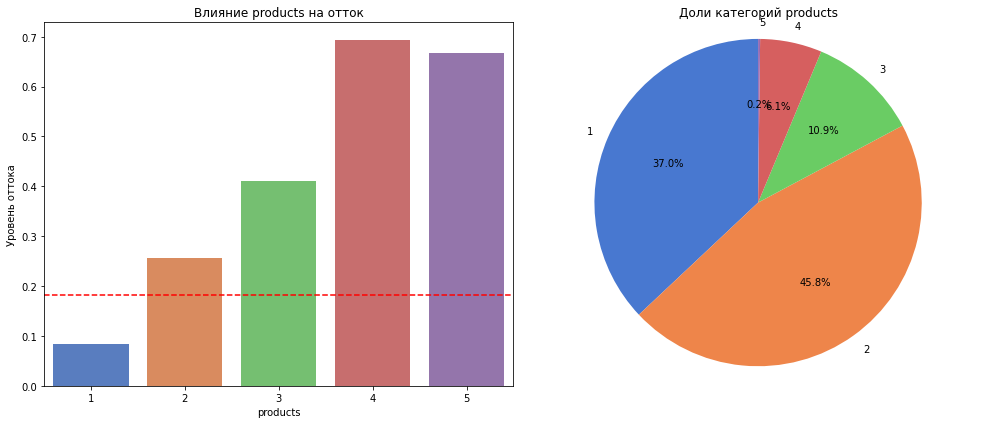

In [169]:
describe_feature(data=claster1,
                 kind='categorical',
                 feature='products',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

У клиентов использующих более 1 продукта склонность к оттоку превышает средний уровень по банку. В основном клиенты пользуются одним или двумя продуктами.

Распрпеделение по владельцам кредитных карт:

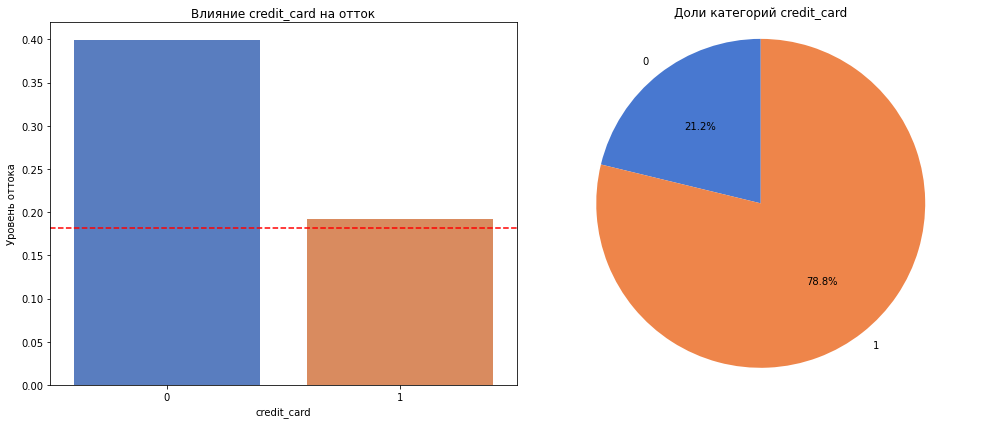

In [109]:
describe_feature(data=claster1,
                 kind='categorical',
                 feature='credit_card',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

79% клиентов имеют кредитную карту, уровень их склонности к оттоку чуть выше среднего уровня. Клиенты без кредитных карт значительно в большей степени склонны к оттоку.

Распределение по активности:

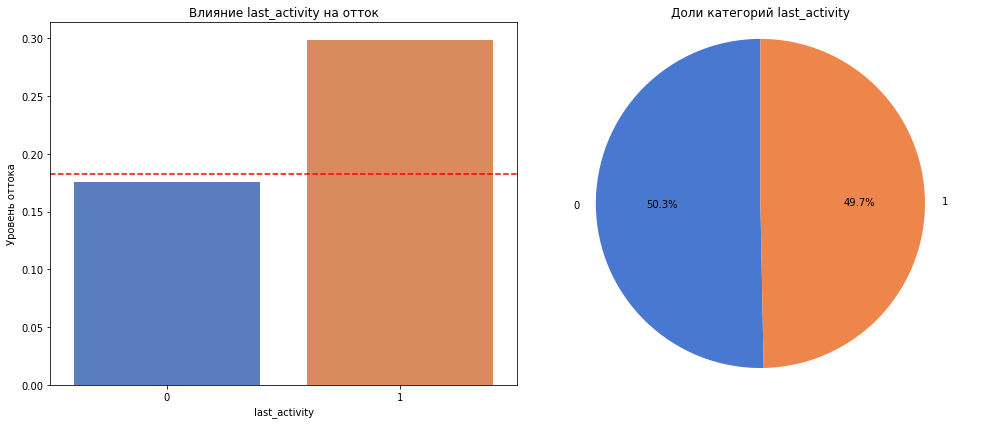

In [170]:
describe_feature(data=claster1,
                 kind='categorical',
                 feature='last_activity',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

Активные и неактивные клиенты распределены равномерно. У неактивных клиентов склонность к оттоку чуть ниже среднего уровня по банку. У активных клиентов склонность к оттоку значительно выше среднего уровня.

#### Кластер 2 - жители Рыбинска

Сделаем срез по клиентам из кластера 2:

In [172]:
claster2 = df_uncoded.query('claster==2')

Рассмотри распределение по возрасту:

Min: 18
Max: 84
Среднее: 43.31
Медиана: 41.00
Ст. откл-е: 12.35


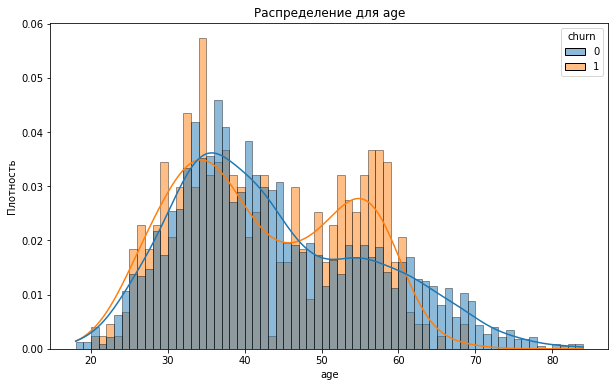

In [173]:
describe_feature(data=claster2,
                 kind='continuous',
                 feature='age',
                 hue='churn')

Средний возраст 43 года. Два пика - 30-45 лет и 50-60 лет. Высокая доля клиентов склонных к оттоку в промежутке до 35 лет, а также 50-60 лет.

Распределение накоплений:

In [174]:
print(f"Min: {claster2['balance'].min()}")
print(f"Max: {claster2['balance'].max()}")
print(f"Среднее: {claster2['balance'].mean():.2f}")
print(f"Медиана: {claster2['balance'].median():.2f}")
print(f"Ст. откл-е: {claster2['balance'].std():.2f}")

fig = px.histogram(
    claster2,
    x='balance',
    color='churn',
    barmode='overlay',
    histnorm='probability',
    labels={'churn': 'Churn'},
    title='Распределение для признака balance',
    opacity=0.5,
    nbins=50
)

# Update layout
fig.update_layout(
    xaxis_title='Balance',
    yaxis_title='Плотность',
    legend_title='Churn'
)

# Show the plot
fig.show()

Min: 6.0
Max: 8936697.19
Среднее: 588298.36
Медиана: 371858.35
Ст. откл-е: 694156.09


Средние накопления 588 тыс.руб. Большая часть клиентов имеет накопления 0.1-1.9 млн руб. Клиенты с накоплениями до 500 тыс. руб менее склонны к оттоку, чем клиенты с большими накоплениями.

Распределение доходов:

In [175]:
print(f"Min: {claster2['est_salary'].min()}")
print(f"Max: {claster2['est_salary'].max()}")
print(f"Среднее: {claster2['est_salary'].mean():.2f}")
print(f"Медиана: {claster2['est_salary'].median():.2f}")
print(f"Ст. откл-е: {claster2['est_salary'].std():.2f}")

fig = px.histogram(
    claster2,
    x='est_salary',
    color='churn',
    barmode='overlay',
    histnorm='probability',
    labels={'churn': 'Churn'},
    title='Распределение для признака est_salary',
    opacity=0.5,
    nbins=50
)

# Update layout
fig.update_layout(
    xaxis_title='Salary',
    yaxis_title='Плотность',
    legend_title='Churn'
)

# Show the plot
fig.show()

Min: 3487.33
Max: 920024.89
Среднее: 134816.22
Медиана: 113335.90
Ст. откл-е: 107502.14


Средняя зарплата - 135 тыс. руб., Есть длинный хвост с зарплатами более 250 тыс. руб. Основная часть клиентов из этого кластера получает доход 10-250 тыс. руб. У клиентов с зарплатой более 130 тыс. руб. склонность к оттоку выше.

Распределение по количеству используемых продуктов:

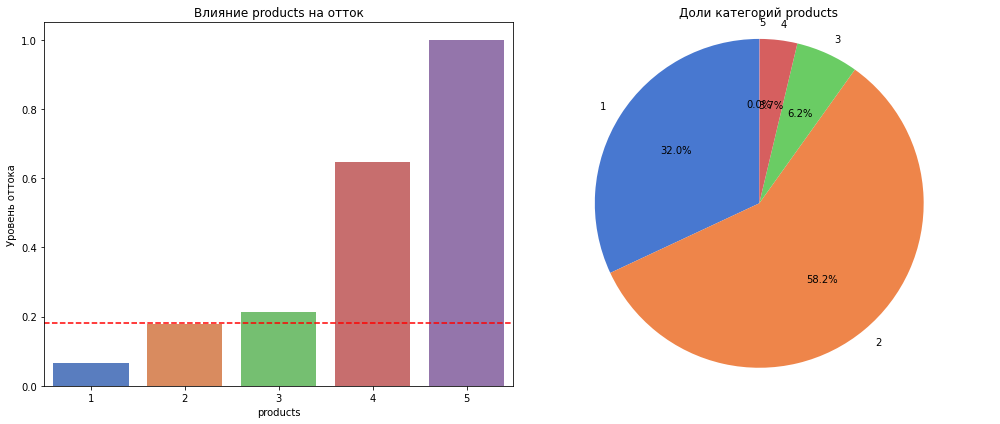

In [176]:
describe_feature(data=claster2,
                 kind='categorical',
                 feature='products',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

Больше всего клиентов в этом кластере используют 1 или 2 продукта. Самый низкий уровень оттока у клиентов с 1 продуктом, у клиентов с 2 продуктами склонность к оттоку на уровне среднего по банку.

Распределение по владельцам кредитных картах:

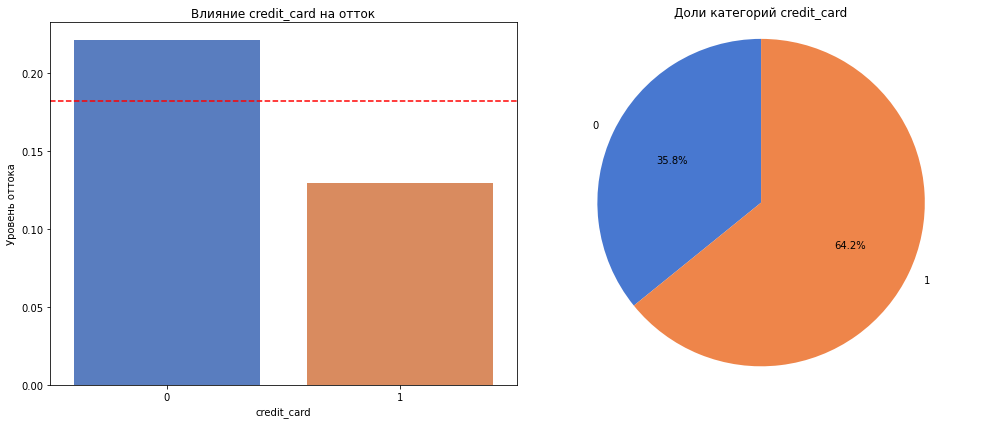

In [177]:
describe_feature(data=claster2,
                 kind='categorical',
                 feature='credit_card',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

64% клиентов имеют кредитную карту, уровень их отточности ниже среднего. У клиентов без кредитной карты склонность к оттоку выше среднего уровня по банку.

Распределение по активности:

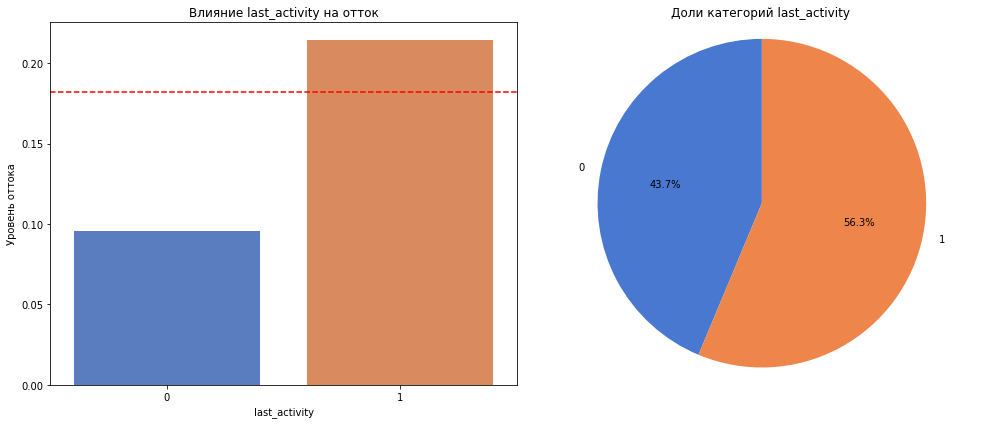

In [178]:
describe_feature(data=claster2,
                 kind='categorical',
                 feature='last_activity',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

Активных пользователей больше половины, их склонность к оттоку выше среднего уровня по банку. У неактивных клиентов склонность к оттоку значительно ниже среднего уровня.

Распределение по полу:

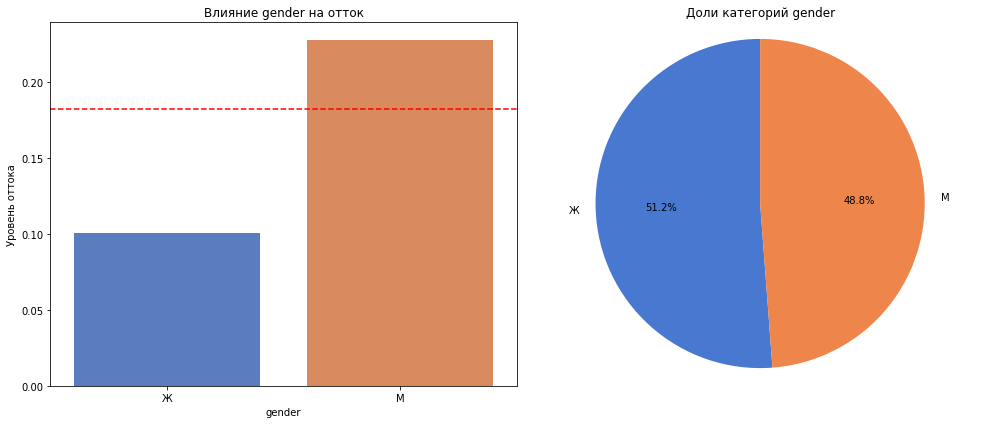

In [179]:
describe_feature(data=claster2,
                 kind='categorical',
                 feature='gender',
                 hue='churn',
                 level=df_uncoded['churn'].mean())

Распределение по полу почти равномерное, женщин ненамного больше, чем мужчин. Как и в других кластерах склонность мужчин к оттоку выше среднего уровня по банку. Женщины гораздо более лояльные.

### Выводы по кластеризации клиентов

С учетом рассмотренных признаков по кластерам, можно обобщить портреты клиентов из каждого кластера:

* **Кластер 0 - жители Ростова**
    * Уровень оттока - на уровне среднего по Банку
    * Средний возраст 44 года (высокая отточность в группах до 30 лет, около 40 лет и 55-60 лет)
    * Средние накопления клиента в данном кластере - 573 тыс. руб. У большей части клиентов данного кластера накопления не превышают 1.5 млн руб. У клиентов с низкими накоплениями (менее 500 тыс. руб) склонность к оттоку ниже.
    * Средняя зарплата - 112 тыс. руб., основная часть клиентов получает доход 20-240 тыс. руб.
    * Более половины клиентов пользуется двумя продуктами. Самые лояльные клиенты те, что пользуются одним продуктом. Наиболее склонные к оттоку клиенты с 3 и 4 продуктами (таких клиентов значительно меньше). У клиентов с двумя продуктами уровень оттока соответствует среднему уровню по Банку.
    * 43% клиентов не пользуются кредитной картой - у таких клиентов отток выше среднего уровня. У клиентов с кредитной картой отток ниже среднего уровня по Банку.
    * У неактивных клиентов (их менее 47%) отток ниже среднего уровня. У активных (более половины клиентов в сегменте) - отток выше среднего.
    * Клиенты распределены по полу равномерно. Женщины менее склонны к оттоку, у мужчин уровень оттока выше среднего по Банку.

* **Кластер 3 - клиенты женского пола из Ярославля**
    * Самый низкий уровень оттока среди всех кластеров
    * Средний возраст 45 лет. Два пика - 30-40 лет и 50-62 года. Высокая доля клиентов склонных к оттоку в промежутке 25-35 лет, а также 50-60 лет.
    * Средние накопления 637 тыс.руб. Большая часть клиентов имеет накопления до 2.25 млн руб. Клиенты с накоплениями до 750 тыс. руб менее склонны к оттоку, чем клиенты с большими накоплениями.
    * Средняя зарплата - 150 тыс. руб., Есть длинный хвост с зарплатами более 250 тыс. руб. Основная часть клиентов из этого кластера получает доход до 250 тыс. руб.
    * У клиентов использующих более 2 продуктов склонность к оттоку превышает средний уровень по банку. В основном клиенты пользуются одним или двумя продуктами.
    * 66% клиентов имеют кредитную карту, уровень их склонности к оттоку ниже среднего. У клиентов без кредитных карт уровень оттока превышает средний по банку.
    * Доли активных и неактивных пользователей сопоставимы, у неактивных пользователей склонность к оттоку значительно ниже среднего уровня по банку, а у активных пользователей выше.
    
* **Кластер 1 - клиенты мужского пола из Ярославля**
    * Кластер с самым высоким уровнем оттока
    * Средний возраст 40 лет. Два пика - 25-45 лет и 50-55 лет. Высокая доля клиентов склонных к оттоку в промежутке 25-30 лет, 35 лет, а также 52-60 лет.
    * Средние накопления 815 тыс.руб., медианные - 347 тыс. руб. Большая часть клиентов имеет накопления до 2.5 млн руб. Есть небольшое количество клиентов с очень высоким уровнем накоплений (более 7.5 млн рублей). Клиенты с накоплениями до 2.5 млн руб менее склонны к оттоку, чем клиенты с большими накоплениями.
    * Средняя зарплата - 175 тыс. руб., Есть длинный хвост с зарплатами более 300 тыс. руб. Основная часть клиентов из этого кластера получает доход до 300 тыс. руб.
    * У клиентов использующих более 1 продукта склонность к оттоку превышает средний уровень по банку. В основном клиенты пользуются одним или двумя продуктами.
    * 79% клиентов имеют кредитную карту, уровень их склонности к оттоку чуть выше среднего уровня. Клиенты без кредитных карт значительно в большей степени склонны к оттоку.
    * Активные и неактивные клиенты распределены равномерно. У неактивных клиентов склонность к оттоку чуть ниже среднего уровня по банку. У активных клиентов склонность к оттоку значительно выше среднего уровня.

* **Кластер 2 - клиенты из Рыбинска**
    * Уровень оттока ниже среднего по Банку
    * Средний возраст 43 года. Два пика - 30-45 лет и 50-60 лет. Высокая доля клиентов склонных к оттоку в промежутке до 35 лет, а также 50-60 лет.
    * Средние накопления 588 тыс.руб. Большая часть клиентов имеет накопления до 0.1-1.9 млн руб. Клиенты с накоплениями до 500 тыс. руб менее склонны к оттоку, чем клиенты с большими накоплениями.
    * Средняя зарплата - 135 тыс. руб., Есть длинный хвост с зарплатами более 250 тыс. руб. Основная часть клиентов из этого кластера получает доход 10-250 тыс. руб. У клиентов с зарплатой более 130 тыс. руб. склонность к оттоку выше.
    * Больше всего клиентов в этом кластере используют 1 или 2 продукта. Самый низкий уровень оттока у клиентов с 1 продуктом, у клиентов с 2 продуктами склонность к оттоку на уровне среднего по банку.
    * 64% клиентов имеют кредитную карту, уровень их отточности ниже среднего. У клиентов без кредитной карты склонность к оттоку выше среднего уровня по банку.
    * Активных пользователей больше половины, их склонность к оттоку выше среднего уровня по банку. У неактивных клиентов склонность к оттоку значительно ниже среднего уровня.
    * Распределение по полу почти равномерное, женщин ненамного больше, чем мужчин. Как и в других кластерах склонность мужчин к оттоку выше среднего уровня по банку. Женщины гораздо более лояльные.


Если еще раз обобщить какие признаки объединяют клиентов склонных к оттоку, но на этот раз по результатам сегментации с использованием алгоритмов машинного обучения, получим следующее:
* **Пол:** женщины-клиенты более лояльные, мужчины клиенты чаще склонны к оттоку
* **Возраст:** склонность к оттоку характерна либо для молодых клиентов (до 35 лет) либо для более взрослых (50-60 лет)
* **Количество используемых продуктов:** как правило у клиентов использующих более 1 продукта банка склонность к оттоку повышается относительно клиентов с одним продуктом, а также часто превышает средний уровень оттока по банку.
* **Наличие кредитной карты:** за исключением сегмента клиентов-мужчин из Ярославля, у клиентов с кредитной картой склонность к оттоку существенно ниже, чем у клиентов без кредитной карты. В сегменте мужчин из Ярославля наблюдается противоположная ситуация.
* **Активность клиентов** у активных клиентов как правило склонность к оттоку превышает средний уровень по банку.

### Выбор наиболее перспективных сегментов и рекомендации по работе с ними

Для таргетированной работы с уровнем оттока клиентов банка отделу маркетинга рекомендуется сконцентрироваться на следующих сегментах:
* Клиенты мужского пола из Ярославля (максимальный уровень склонности к оттоку среди обнаруженных сегментов)
* Клиенты - жители Ростова (уровень оттока средний по банку)

**Для клиетов-мужчин из Ярославля предлагаются следующие рекомендации:**
* Специальные условия по вкладам (повышенный процент) - у клиентов из этого сегмента накопления больше чем в других сегментах, поэтому данная акция может заинтерсовать клиентов
* С учетом того, что в данном сегменте клиенты с кредитной картой более склонны к оттоку чем клиенты без нее - предлагается также добавить специальные условия по обслуживанию кредитных карт для клиентов данного сегмента - увеличить беспроцентный период (например с 30 до 60 или 90 дней), предложить гибкую процентную ставку в зависимости от оборота - чем выше оборот, тем больше скидка к процентной ставке.
* Предложить специальные условия по автокредитованию (пониженная ставка + ОСАГО в подарок)
* Категории повышенного кэшбэка - топливо, автосервис, строительные магазины, а также развлечения, бронирование билетов и гостиниц (для более молодой части сегмента)

Особо рекомендуется уделять внимание клиентам из данного сегмента имеющим кредитную карту, активно пользующимся мобильным банком / личным кабинетом или пользующихся более чем одним продуктом.

**Для клиетов из Ярославля предлагаются следующие рекомендации:**
* Повысить долю владельцев кредитных карт - предлагать специальные условия по обслуживанию (увеличеный беспроцентный период, гибкая процентная ставка)
* Для клиентов мужчин (наиболее склонны к оттоку) предлагать категории повышенного кэшбэка (топливо, автосервис, товары для дачи и сада)
* Предлагать пакет услуг с бесплатным обслуживанием (для клиентов с повышенным риском оттока)
* Предлагать услугу по начислению процентов на остаток по дебетовой карте (ставка должна быть значительно ниже ставки по вкладам и накопительным счетам, но психологически привлекательной, например 5% годовых)

В данном сегменте особое внимание необходимо уделять клиентам без кредитных карт, пользующихся более чем одним продуктом, клиентам мужского пола, а также клиентам активнос пользующихся мобильным банком / личным кабинетом.

Общая рекомендация по работе с оттоком - поддерживать в актуальном состоянии базу данных клиентов с разметкой пользователей которые ушли в отток, периодически запускать обучение модели и актуализироать характеристики кластеров, находить новые.

Также предлагается разработать прогнозную модель предсказывающую вероятность оттока на основе имеющихся данных (могут быть использованы данные с которыми работали) - тогда будет возможность превентивно и точечно работать с клиентами которые не ушли в отток, но по данным модели вероятность его высока.

## Общий вывод по исследованию

<ins>**Общая информация о датасете**<ins>
* Получен датасет содержащий 10000 записей с 12 признаками. В целом датасет представляет из себя набор записей, состоящих из:
    * основной информации о клиенте (идентификатор, пол, возраст, город),
    * финансовые показатели клиента (кредитный скоринг, баллы собственности, баланс на счёте, оценочный доход)
    * показатели взаимодействия с банком (количество используемых продуктов, наличие кредитной карты Банка, активность за последние 30 дней, признак отточности)


<ins>**Предобработка данных**<ins>    
* Привели наименование столбцов к нижнему регистру
* Закодировали категориальные признаки методом `get_dummies` из библиотеки `Pandas`

**Обработка пропусков**
* Обнаружили две колонки с пропусками - age и balance:
    * Пропуски по поллю `age` 26 шт. или 0.26%
    * Пропуски по поллю `balance` 2295 шт. или 22.95%
* Пропуски по полю `age`:
    * Ни одной значимой корреляции между пропусками и другими признаками не обнаружено, следовательно можно предположить, что данные пропуски возникли случайно, то есть данный вид пропусков можно классифицировать как MCAR-пропуски (пропуски данных происходят случайным образом, и их наличие не зависит ни от наблюдаемых, ни от ненаблюдаемых данных).
    * Пропуски удалены.

* Пропуски по полю `balance`:
    * Пропуски в балансе коррелируют с количеством продуктов и баллами собственности
    * Пропуски в балансе можно классифицировать как MAR-пропуски (пропуски зависят от наблюдаемых данных, но не от самих пропущенных значений)
    * Для заполнения пропусков подготовили сводную таблицу по количеству используемых продуктов и баллам собственности и посчитали медианные значения для каждой группы. Функцией заполнили все пропущенные значения в зависимости от того в какую группу попал клиент с пропущенным балансом по количеству используемых продуктов и баллам собственности.
    
**Обработка типов данных**
* Поля `age` и `score` представленные в исходном датасете в вещественном типе привели к целочисленному типу данных.

**Обработка дубликатов данных**
* Явных дубликатов (полных совпадений строк не обнаружено)
* Найдены 73 дубликата по полю `userid`, но признаки клиентов с одинаковыми идентификаторами отличаются, что говорит о возможной технической ошибке при выгрузке данных.
* В результате обработки дубликатов данные не удалялись.
    
<ins>**Исследовательский анализ данных**<ins>

**Описательная статистика признаков**
* Основная информация о клиентах:
    * `age`:
        * Возраст клиентов Банка находится в диапозоне 18-86 лет.
        * На гистограмме распределения два пика плотности клиентов по возрастам - первый находится между 30 и 40 годами, второй меньший пик - 50-60 лет.
        * Средний возраст клиента - 43 года.
        * Возраст основной части клиентов Банка - 31 - 55 лет.
        * После 60 лет клиенты менее склонны к оттоку, также с 40 до 50 лет клиенты реже склонны к оттоку.
        * Наибольшая доля клиентов склонных к оттоку находится в диапозонах 25-35 лет и 51-60 лет. 
    
    * `gender`:
        * Получили, что женщины более консервативны и склонность к оттоку у них ниже среднего, а мужчины наоборото более склонны к оттоку.
        * Клиенты по полу распределны поровну.
    
    * `city`:
        * 59% клиентов Банка живут в Ярославле (областной центр)
        * Самые лояльные клиенты живут в Рыбинске.
        * Склонность к оттоку у клиентов из Ростова и Ярославля сопоставима и чуть выше среднего уровня.

* Финансовые показатели клиентов:
    
    * `score`:
        * Баллы кредитного рейтинга варьируются в диапозоне 642 - 1000.
        * Средний кредитный рейтинг клиентов - 849 баллов.
        * Основная часть клиентов имеет кредитный рейтинг в диапозоне 780-900 баллов.
        * В диапозоне 825 - 900 преобладают клиенты склонные к оттоку, пик отточности приходится примерно на 875 баллов.
        * Клиенты со средним и высоким кредитным рейтингом склонны к оттоку, это необходимо иметь в виду при планировании маркетинговых акций и формировании персональных предложений для клиентов.
    
    * `equity`:
        * Наиболее лояльные клиенты с уровнем оттока ниже среднего имеют в собственности не более двух объектов. Максимальный уровень лояльности - у клиентов без собственности (менее 5%).
        * Более всего к оттоку склонны клиенты с большим количеством собственности - более 5 объектов.
        * Меньше всего клиентов с количеством собственности более 5.
        * Клиенты с количеством собственности до 5 распределны относительно равномерно, особо выделяется группа без собственности - 26% и клиенты имеющие 5 объектов собственности - 19%.
    
    * `balance`:
        * Максимальный баланс клиента - 119 млн руб.
        * Видим скошенное вправо распределение с длинным "хвостом" аномально высоких балансов
        * Средний баланс - 668 тыс. руб. медианный - 376 тыс.руб. Средний значительно выше медианного за счет наличия экстремально больших значений
        * Основная доля значений находится в диапозоне 0-2.5 млн.
        * У клиентов с балансом до 1.2 млн и свыше 2.6 млн доля склонных к оттоку выше.
    
    * `est_salary`:
        * Зарплаты клиентов варьируются в диапозоне 3 тыс - 1.4 млн руб.
        * Основная часть клиентов получает зарплату в диапозоне 50-200 тыс. руб.
        * Среди клиентов с зарплатой до 100 тыс. доля отточных ниже, чем лояльных
        * Среди клиентов с зарплатой от 100 до 200 тыс. доля склонных к оттоку выше.
        * У клиентов с зарплатой от 200 тыс. доли склонных и не склонных к оттоку практически идентичны.
        * Зарплаты выше 300 тыс встречаются крайне редко


* Показатели взаимодействия с банком:
    * `products`:
        * Самые лояльные клиенты - те, что пользуются только одним продуктом.
        * Клиенты с двумя продуктами находятся примерно на уровне среднего оттока по всем клиентам.
        * У клиентов пользующихся разнообразными продуктами банка (3-5 продукта) уровень оттока выше среднего.
        * Чаще всего клиенты пользуются одним или двумя продуктами Банка.
        * Клиентов пользующихся более чем тремя продуктами очень мало.
    
    * `credit_card`:
        * Из полученного графика видно, что клиенты имеющие кредитную карту Банка значительно лояльнее чем клиенты без кредитной карты.
        * 68% клиентов Банка имеют кредитную карту, но у оставшихся 32% склонность к оттоку выше среднего (примерно четверть из них может уйти из Банка).
    
    * `last_activity`:
        * У активных клиентов склонность к оттоку выше средней, в то время как у неактивных клиентов уровень оттока ниже среднего.
        
**Средние значения признаков по группам отточности**
* Обе группы отточности клиентов не существенно отличаются по признаку средних/медианных балоов кредитного скорринга (у клиентов с оттоком они выше на 2%)
* Средний возраст лояльного клиента - 43 года, склонного к оттоку - 41. Медианы для обеих групп меньше среднего (40 и 39 соответственно), значит есть смещение возраста клиентов в большую сторону.
* У клиентов склонных к оттоку медианный бал собственности - 4, у лояльных клиентов - 3.
* Существенно отличаются средние и медианные балансы клиентов из двух групп - у клиентов склонных к оттоку средний баланс выше чем у лояльных на 99%, медианный на 142%. Различие средних и медиан также объясняется смещением распределения вправо (наличие аномально высоких значений)
* Медианное количество используемых продуктов для двух групп не отличается и равно двум.
* У клиентов склонных к оттоку на 23% реже встречается кредитная карта Банка.
* Клиенты склонные к оттоку на 45% активнее лояльных клиентов. Так среди лояльных клиентов активны только 48%, среди клиентов склонных к оттоку - 70%.
* Средние зарплаты обеих групп отличаются не существенно, а медианная зарплата клиентов склонных к оттоку на 6% выше чем у лояльных клиентов. Средние зарплаты также получились выше медианных, что говорит о смещении рапспределения в большую сторону (наличие аномально высоких зарплат у некоторых клиетов).
    
    
**Сравнение портретов пользователей по группам отточности**
**Лояльные клиенты**
* Женщины в возрасте 45-47 лет проживающие преимущественно в Рыбинске и Ярославле
    * Имеют три объекта собственности
    * Получают зарплату в диапазоне 101-150 тыс руб.
    * Баланс счета 518-566 тыс.руб.
    * Имеют кредитную карту 53-69% в зависимости от города
    * Активны 46-54% клиентов

* Мужчины в возрасте 39-40 лет проживающие преимущественно в Рыбинске и Ярославле:
    * Имеют два объекта собственности
    * Получают зарплату в диапазоне 118-180 тыс. руб.
    * Баланс счета 473-645 тыс. руб.
    * Имеют кредитную карту 63-83% в зависимости от города
    * Активны 46-51% клиентов

* Лояльные клиенты-женщины старше аналогичной группы мужчин, имеют больше недвижимости по сравнению с мужчинами, реже имеют кредитную карту, уровень зарплаты ниже чем у мужчин.


**Клиенты склонные к оттоку**
* Женщины в возрасте 42-46 лет проживающие преимущественно в Рыбинске и Ярославле
    * Имеют четыре объекта собственности
    * Получают зарплату в диапозоне 120-149 тыс руб.
    * Баланс счета 800-1063 тыс.руб.
    * Имеют кредитную карту 36-47% в зависимости от города
    * Активны 72-82% клиентов

* Мужчины в возрасте 39-40 лет проживающие преимущественно в Рыбинске и Ярославле:
    * Имеют четыре объекта объекта собственности
    * Получают зарплату в диапозоне 123-166 тыс. руб.
    * Баланс счета 948-1367 тыс. руб.
    * Имеют кредитную карту 56-64% в зависимости от города
    * Активны 63-72% клиентов

Характерные отличия получившихся групп:
* Женщины старше мужчин, реже имеют кредитную карту чем мужчины, получают меньшую зарплату, имеют меньше накопленией, реже склонны к оттоку.
* Мужчины чаще имеют кредитные карты, получают зарплату больше женщин и имеют более высокие накопления.
* Лояльные клиенты имеют меньше собственности, меньшие накопления, чаще пользуются кредитными картами по сравнению с клиентами, склонными к оттоку.


**Анализ корреляции признаков датасета**
* Корреляция с признакоом оттока:
    * сильной корреляции нет ни с одним признаком
    * умеренная корреляция (0.44) есть с количеством используемых продуктов
    * слабая коррелляция есть с полом (0.22), кредитным скоррингом (0.23), активностью (0.26), наличием кредитной карты (0.20) и количеством собственности (0.35) - сегментация пользователей по всем этим признакам была приведена выше.
* Сильные корреляции между другими признаками в датасете отсутствуют
* Умеренные корреляции:
    * количество собственности - кредитный скорринг (0.53) - логичная связь, чем больше собственности тем выше должен быть кредитный рейтинг
    * количество собственности - количество используемых продуктов (0.44)
    * наличие кредитной карты - количество используемых продуктов (0.46) - логичная связь, наличие кредитной карты расширяет количество базовых услуг банка.
    * зарплата - кредитный скорринг (0.40) - логичная свзяь, чем больше доход тем выше кредитный рейтинг
* Все остальные признаки имеют слабую и очень слабую корреляцию.
    
    
<ins>**Проверка гипотез**<ins>    
**Гипотеза о различии доходов между клиентами, которые склонны и не склонны к уходу из Банка**
* В выборках для теста есть существенные выбросы, не выполнены два критерия ограничивающих применение t-теста - равномерность и равенство дисперсий. 
* Для проверки гипотезы использован U-тест Манна-Уитни.
* Тест показал, что есть статистически значимая разница между доходами клиентов, которые склонны к оттоку и которые не склонны к оттоку. 
* Подтвердилась гипотеза о различии в доходох клиентов по группам отточности.

**Проверка гипотезы о равенстве возраста клиентов мужчин и клиентов женщин**
* Для данной гипотезы также будем использован U-тест Манна-Уитни, так как не выполнены два ограничивающих критерия применения t-теста - равномерность распределения выборок и равенство дисперсий.
* Тест показал, что есть статистически значимая разница между возрастом клиентов женщин и клиентов мужчин.
* Гипотеза об отсутствии различий в возрасте клиентов по полу не подтвердилась.
    
**Проверка гипотезы о более высоких доходах владельцев кредитных карт по сравнению с клиентами без кредитных карт**
* Для данной гипотезы использован U-тест Манна-Уитни, так как не выполнены три ограничивающих критерия применения t-теста - равномерность распределения выборок и равенство дисперсий, отсутствие выбросов
* Тест показал, что есть статистически значимая разница между доходами клиентов с кредитными картами и без кредитных карт. 
* Гипотеза о более высоких доходов владельцев кредитных карт по сравнению с клиентами без кредитных карт подтвердилась.
    
<ins>**Подведение промежуточных итогов**<ins>
На основе исследованных признаков клиентов Банка предложены следующие сегменты для таргетированной работы по снижению количества пользователей, склонных к оттоку:
* **"Клиенты без кредитных карт"**
    * В сегменте клиентов без кредитной карты оказалось 815 целевых клиентов, склонных к оттоку. С такими клиентами необходимо работать в направлении оформления кредитной карты (разумеется с учетом возможных рисков и платежеспособности клиента).

* **"Клиенты моложе 41 года"**
    * В данном сегменте оказалось более 1000 целевых клиентов. С учетом молодого возраста клиентов необходимо подбирать специальные предложения с учетом интересов данной возрастной категории. 
    * Для данной группы можно предложить следующий набор опций:
        * Молодежные кредитны карты с пониженной процентной ставкой и бесплатным обслуживанием
        * Кредиты на образование
        * Повышенный кэшбэк на категории развлечений, путешествий, образования
    * Также необходимо повышать удобство работы с мобильным приложением, так как клиенты данной возрастной категории как правило активно пользуются мобильным банком - можно добавить функционал покупки билетов в кино и на другие события (концерты, театр, стендап и т.д.), возможность бронирования гостиниц и авиа/жд билетов.

* **"Активные клиенты"**
* В данном сегменте оказалось 1277 целевых клиентов. 
* С учетом того, что в данную группу попали те, кто регулярно заходит в мобильны банк / личный кабинет, для повышения лояльности данной группы необходимо работать над качествоим, надежностью и удобством мобильного приложения, возможно делать из него "суперап", то есть приложение, где в одном месте можно решать большинство повседневных задач связанных с платежами - оплата коммунальных услуг, образовательных услуг для детей, удобное управление счетами и вкладами, бронирование гостиниц и билетов и т.д.

* **"Клиенты имеющие более 3-х баллов собственности"**
* В данном сегменте получили более 1100 целевых клиентов. Для данной группы с учетом значительного количества собственности для удержания таких клиентов можно предложить специальные условия страхования недвижимости (от пожара, затопления и т.д.), особые тарифы на страхование транспортных средств, пакетные предложения охватывающие все объекты собственности с существенной скидкой. Также можно рассмотреть возможность предложения таким клиентам премиального пакета обслуживания без дополнительной платы (прописать условия по доходу, остаткам на счетах, использованию страховых программ для максимального охвата данной категории и повышению вероятности акцепта клиента)

<ins>**Сегментация пользователей банка**<ins>
* С помощью иерархической кластеризации определено оптимальное количество кластеров, которое в нашем случае получилось равным 4
* С помощью алгоритма K-means выполнена кластеризация клиентов на на 4 кластера
* Анализ полученных кластеров выявил следующие характерные группы пользователей:
    * **Кластер 0 - жители Ростова**
    * Уровень оттока - на уровне среднего по Банку
    * Средний возраст 44 года (высокая отточность в группах до 30 лет, около 40 лет и 55-60 лет)
    * Средние накопления клиента в данном кластере - 573 тыс. руб. У большей части клиентов данного кластера накопления не превышают 1.5 млн руб. У клиентов с низкими накоплениями (менее 500 тыс. руб) склонность к оттоку ниже.
    * Средняя зарплата - 112 тыс. руб., основная часть клиентов получает доход 20-240 тыс. руб.
    * Более половины клиентов пользуется двумя продуктами. Самые лояльные клиенты те, что пользуются одним продуктом. Наиболее склонные к оттоку клиенты с 3 и 4 продуктами (таких клиентов значительно меньше). У клиентов с двумя продуктами уровень оттока соответствует среднему уровню по Банку.
    * 43% клиентов не пользуются кредитной картой - у таких клиентов отток выше среднего уровня. У клиентов с кредитной картой отток ниже среднего уровня по Банку.
    * У неактивных клиентов (их менее 47%) отток ниже среднего уровня. У активных (более половины клиентов в сегменте) - отток выше среднего.
    * Клиенты распределены по полу равномерно. Женщины менее склонны к оттоку, у мужчин уровень оттока выше среднего по Банку.

* **Кластер 3 - клиенты женского пола из Ярославля**
    * Самый низкий уровень оттока среди всех кластеров
    * Средний возраст 45 лет. Два пика - 30-40 лет и 50-62 года. Высокая доля клиентов склонных к оттоку в промежутке 25-35 лет, а также 50-60 лет.
    * Средние накопления 637 тыс.руб. Большая часть клиентов имеет накопления до 2.25 млн руб. Клиенты с накоплениями до 750 тыс. руб менее склонны к оттоку, чем клиенты с большими накоплениями.
    * Средняя зарплата - 150 тыс. руб., Есть длинный хвост с зарплатами более 250 тыс. руб. Основная часть клиентов из этого кластера получает доход до 250 тыс. руб.
    * У клиентов использующих более 2 продуктов склонность к оттоку превышает средний уровень по банку. В основном клиенты пользуются одним или двумя продуктами.
    * 66% клиентов имеют кредитную карту, уровень их склонности к оттоку ниже среднего. У клиентов без кредитных карт уровень оттока превышает средний по банку.
    * Доли активных и неактивных пользователей сопоставимы, у неактивных пользователей склонность к оттоку значительно ниже среднего уровня по банку, а у активных пользователей выше.
    
* **Кластер 1 - клиенты мужского пола из Ярославля**
    * Кластер с самым высоким уровнем оттока
    * Средний возраст 40 лет. Два пика - 25-45 лет и 50-55 лет. Высокая доля клиентов склонных к оттоку в промежутке 25-30 лет, 35 лет, а также 52-60 лет.
    * Средние накопления 815 тыс.руб., медианные - 347 тыс. руб. Большая часть клиентов имеет накопления до 2.5 млн руб. Есть небольшое количество клиентов с очень высоким уровнем накоплений (более 7.5 млн рублей). Клиенты с накоплениями до 2.5 млн руб менее склонны к оттоку, чем клиенты с большими накоплениями.
    * Средняя зарплата - 175 тыс. руб., Есть длинный хвост с зарплатами более 300 тыс. руб. Основная часть клиентов из этого кластера получает доход до 300 тыс. руб.
    * У клиентов использующих более 1 продукта склонность к оттоку превышает средний уровень по банку. В основном клиенты пользуются одним или двумя продуктами.
    * 79% клиентов имеют кредитную карту, уровень их склонности к оттоку чуть выше среднего уровня. Клиенты без кредитных карт значительно в большей степени склонны к оттоку.
    * Активные и неактивные клиенты распределены равномерно. У неактивных клиентов склонность к оттоку чуть ниже среднего уровня по банку. У активных клиентов склонность к оттоку значительно выше среднего уровня.

* **Кластер 2 - клиенты из Рыбинска**
    * Уровень оттока ниже среднего по Банку
    * Средний возраст 43 года. Два пика - 30-45 лет и 50-60 лет. Высокая доля клиентов склонных к оттоку в промежутке до 35 лет, а также 50-60 лет.
    * Средние накопления 588 тыс.руб. Большая часть клиентов имеет накопления до 0.1-1.9 млн руб. Клиенты с накоплениями до 500 тыс. руб менее склонны к оттоку, чем клиенты с большими накоплениями.
    * Средняя зарплата - 135 тыс. руб., Есть длинный хвост с зарплатами более 250 тыс. руб. Основная часть клиентов из этого кластера получает доход 10-250 тыс. руб. У клиентов с зарплатой более 130 тыс. руб. склонность к оттоку выше.
    * Больше всего клиентов в этом кластере используют 1 или 2 продукта. Самый низкий уровень оттока у клиентов с 1 продуктом, у клиентов с 2 продуктами склонность к оттоку на уровне среднего по банку.
    * 64% клиентов имеют кредитную карту, уровень их отточности ниже среднего. У клиентов без кредитной карты склонность к оттоку выше среднего уровня по банку.
    * Активных пользователей больше половины, их склонность к оттоку выше среднего уровня по банку. У неактивных клиентов склонность к оттоку значительно ниже среднего уровня.
    * Распределение по полу почти равномерное, женщин ненамного больше, чем мужчин. Как и в других кластерах склонность мужчин к оттоку выше среднего уровня по банку. Женщины гораздо более лояльные.

    
* **Рекомендации для отдела маркетинга:**

Для таргетированной работы с уровнем оттока клиентов банка отделу маркетинга рекомендуется сконцентрироваться на следующих сегментах:
* Клиенты мужского пола из Ярославля (максимальный уровень склонности к оттоку среди обнаруженных сегментов)
* Клиенты - жители Ростова (уровень оттока средний по банку)

**Для клиетов-мужчин из Ярославля предлагаются следующие рекомендации:**
* Специальные условия по вкладам (повышенный процент) - у клиентов из этого сегмента накопления больше чем в других сегментах, поэтому данная акция может заинтерсовать клиентов
* С учетом того, что в данном сегменте клиенты с кредитной картой более склонны к оттоку чем клиенты без нее - предлагается также добавить специальные условия по обслуживанию кредитных карт для клиентов данного сегмента - увеличить беспроцентный период (например с 30 до 60 или 90 дней), предложить гибкую процентную ставку в зависимости от оборота - чем выше оборот, тем больше скидка к процентной ставке.
* Предложить специальные условия по автокредитованию (пониженная ставка + ОСАГО в подарок)
* Категории повышенного кэшбэка - топливо, автосервис, строительные магазины, а также развлечения, бронирование билетов и гостиниц (для более молодой части сегмента)

Особо рекомендуется уделять внимание клиентам из данного сегмента имеющим кредитную карту, активно пользующимся мобильным банком / личным кабинетом или пользующихся более чем одним продуктом.

**Для клиетов из Ростова предлагаются следующие рекомендации:**
* Повысить долю владельцев кредитных карт - предлагать специальные условия по обслуживанию (увеличеный беспроцентный период, гибкая процентная ставка)
* Для клиентов мужчин (наиболее склонны к оттоку) предлагать категории повышенного кэшбэка (топливо, автосервис, товары для дачи и сада)
* Предлагать пакет услуг с бесплатным обслуживанием (для клиентов с повышенным риском оттока)
* Предлагать услугу по начислению процентов на остаток по дебетовой карте (ставка должна быть значительно ниже ставки по вкладам и накопительным счетам, но психологически привлекательной, например 5% годовых)

В данном сегменте особое внимание необходимо удилять клиентам без кредитных карт, пользующихся более чем одним продуктом, клиентам мужского пола, а также клиентам активнос пользующихся мобильным банком / личным кабинетом.

Общая рекомендация по работе с оттоком - поддерживать в актуальном состоянии базу данных клиентов с разметкой пользователей которые ушли в отток, периодически запускать обучение модели и актуализироать характеристики кластеров, находить новые.

Также предлагается разработать прогнозную модель предсказывающую вероятность оттока на основе имеющихся данных (могут быть использованы данные с которыми работали) - тогда будет возможность превентивно и точечно работать с клиентами которые не ушли в отток, но по данным модели вероятность его высока.